# 10/09 1632

## claude with correct wilco

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

In [2]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM_CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [3]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

In [4]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_disease_27_05_results/test_files_standard_disease_27_05_final.parquet"
df_standard = load_and_prepare_results(parquet_path)
df_standard= df_standard.query('feature_clean.isin(@feature_order)')

parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results/test_files_standard_celltype_18_05_final.parquet"
df_celltype_standard = load_and_prepare_results(parquet_path)
df_celltype_standard= df_celltype_standard.query('feature_clean.isin(@feature_order)')



In [5]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_disease_27_05_results/test_files_low_disease_27_05_final1632.parquet"
df_disease_low = load_and_prepare_results(parquet_path)

In [6]:
df_disease_low= df_disease_low.query('feature_clean.isin(@feature_order)')

In [7]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results/test_files_low_celltype_18_05_final1632.parquet"
df_celltype_low = load_and_prepare_results(parquet_path)

In [8]:
results_dataset_f1

NameError: name 'results_dataset_f1' is not defined

DISEASE (F1_macro) tier boundaries: 0.49316426900699106 0.6470136664612979
difficulty_tier
Hard      288
Medium    286
Easy      288
Name: count, dtype: int64

CELL TYPE (F1_macro) tier boundaries: 0.8136372391772877 0.9272215583362002
difficulty_tier
Hard      21
Medium    20
Easy      21
Name: count, dtype: int64


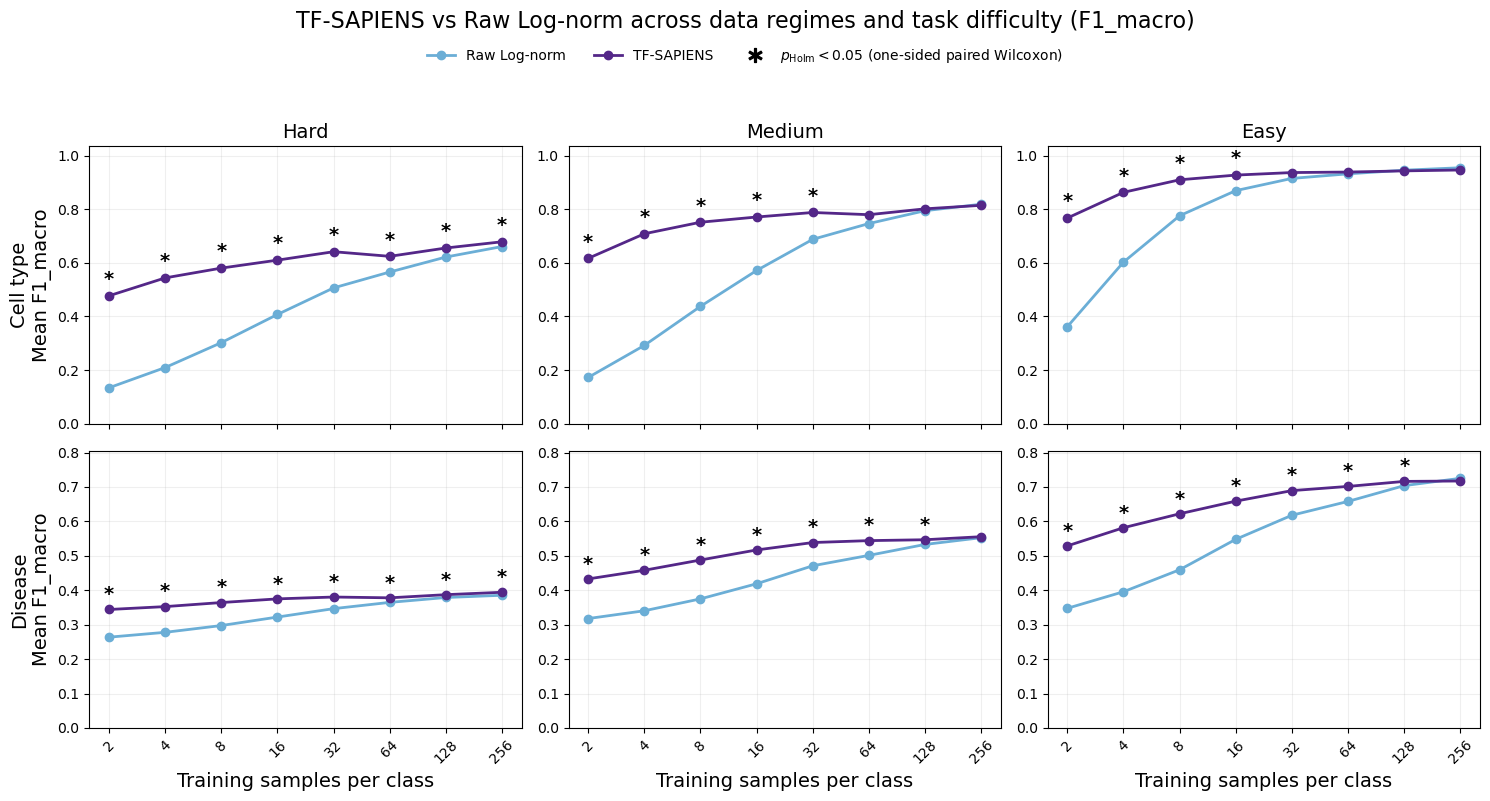

NameError: name 'results_task_mcc' is not defined

In [34]:
from fm_difficulty_analysis import *
N_SHORT = (2, 4, 8, 16, 32, 64, 128, 256)

# --- Setup (once) ---
disease_full, celltype_full, disease_low, celltype_low = prepare_datasets(
    df_standard, df_celltype_standard, df_disease_low, df_celltype_low
)
difficulty_disease, difficulty_ct, boundaries = compute_difficulty(disease_full, celltype_full, metric="F1_macro")
disease_low, celltype_low = merge_difficulty(disease_low, celltype_low, difficulty_disease, difficulty_ct)
'''
# --- Run on MCC ---
results_task_mcc    = compute_model_vs_reference(disease_low, celltype_low, metric="MCC", level="task")
results_dataset_mcc = compute_model_vs_reference(disease_low, celltype_low, metric="MCC", level="dataset")
tier_dataset_mcc    = compute_benchmark_delta_comparison(disease_low, celltype_low, metric="MCC", level="dataset")

fig1 = plot_absolute_metric_by_tier(results_dataset_mcc, metric="MCC")
fig2 = plot_winrate_by_tier(results_task_mcc)
fig3 = plot_delta_by_tier_comparison(tier_dataset_mcc, metric="MCC")
'''
# --- Same everything, on F1_macro instead ---
results_dataset_f1 = compute_model_vs_reference(disease_low, celltype_low, metric="F1_macro", level="dataset", n_values=N_SHORT)
fig1_f1 = plot_absolute_metric_by_tier(results_dataset_f1, metric="F1_macro", n_values=N_SHORT,
                                      save_path="plots_brief/TF_vs_Raw_absolute_F1_by_difficulty.png")

# --- Sensitivity check: did dataset-level correction flip any calls? ---
flips = sensitivity_check(results_task_mcc, results_dataset_mcc, ["benchmark", "tier", "n_per_class"])

In [32]:
import importlib
import fm_difficulty_analysis
importlib.reload(fm_difficulty_analysis)

from fm_difficulty_analysis import *

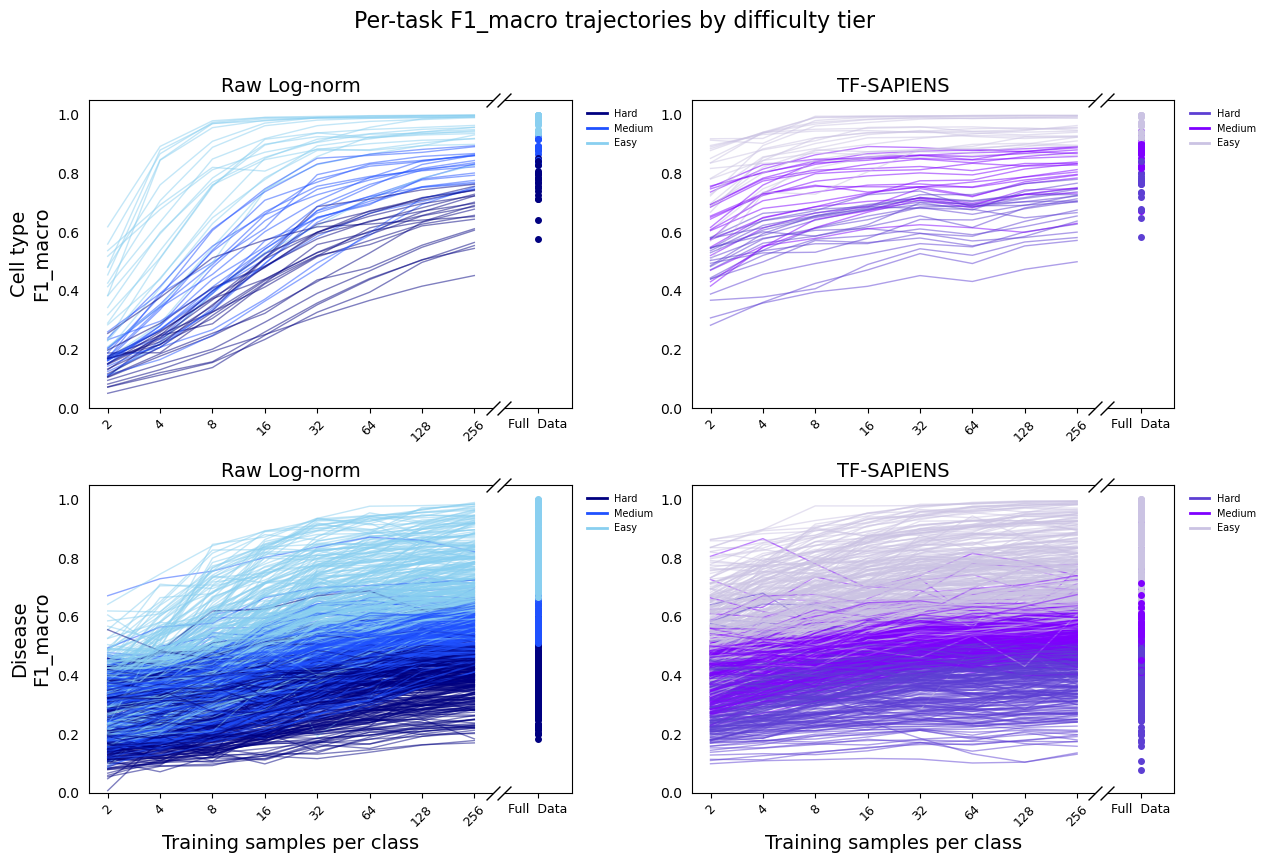

In [23]:
disease_low  = disease_low[disease_low["n_per_class"] <= 256]
celltype_low = celltype_low[celltype_low["n_per_class"] <= 256]

# Same plot on F1_macro:
fig4_f1 = plot_task_trajectories_2x2(
    disease_low, disease_full, celltype_low, celltype_full,
    difficulty_disease, difficulty_ct,
    metric="F1_macro",n_values=N_SHORT,
    save_path="plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2"

)

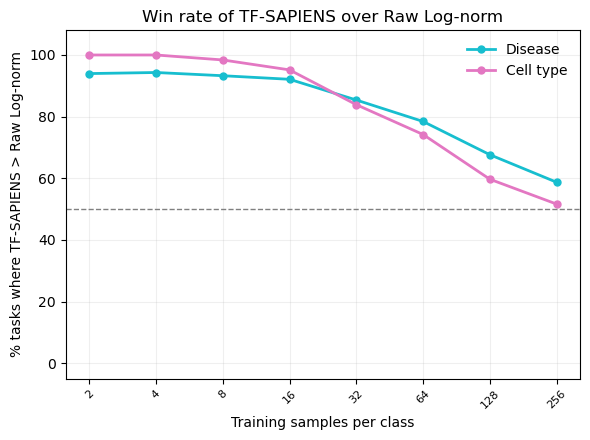

In [30]:
results_overall = compute_model_vs_reference_overall(disease_low, celltype_low, metric="F1_macro")
fig = plot_winrate_overall(results_overall, n_values=N_SHORT,
    save_path="plots_brief/Raw_TF_F1_macro_percent.png"
)

In [33]:
results_overall

,benchmark,n_per_class,n_units,reference_mean,model_mean,delta_mean,delta_median,win_rate,p_raw,p_holm,significant
0,Disease,2,862,0.299840,0.433475,0.133634,0.128481,93.967517,6.574985e-133,4.602489e-132,True
1,Disease,4,862,0.330442,0.467727,0.137285,0.131727,94.315545,5.783214e-136,4.626571e-135,True
2,Disease,8,862,0.375312,0.498713,0.123401,0.117501,93.271462,6.310767e-132,3.786460e-131,True
3,Disease,16,862,0.427201,0.525834,0.098633,0.092894,92.111369,3.840028e-123,1.920014e-122,True
4,Disease,32,862,0.480653,0.547515,0.066862,0.060902,85.382831,2.007923e-99,8.031692e-99,True
5,Disease,64,862,0.510588,0.553926,0.043337,0.041906,78.422274,3.858170e-70,1.157451e-69,True
6,Disease,128,862,0.542822,0.563051,0.020229,0.020670,67.633411,3.648661e-28,7.297322e-28,True
7,Disease,256,862,0.561611,0.569474,0.007863,0.009014,58.700696,4.965593e-08,4.965593e-08,True
8,Cell type,2,62,0.223363,0.620718,0.397355,0.398008,100.000000,3.788883e-12,3.031106e-11,True
9,Cell type,4,62,0.369284,0.705482,0.336197,0.375471,100.000000,3.788883e-12,3.031106e-11,True


DISEASE tier boundaries: 0.19824595227210698 0.4655338643208424
difficulty_tier
Hard      287
Medium    287
Easy      288
Name: count, dtype: int64

CELL TYPE tier boundaries: 0.8578261139928982 0.9362361877522034
difficulty_tier
Hard      21
Medium    20
Easy      21
Name: count, dtype: int64

=== #2 sensitivity: TF-vs-Raw significance flips after dataset collapse ===
   benchmark    tier  n_per_class  n_datasets  delta_mean  significant_task  \
2    Disease    Hard            8          57    0.012347              True   
4    Disease    Hard           32          57    0.018094              True   
5    Disease    Hard           64          57    0.014769              True   
6    Disease    Hard          128          57    0.014120              True   
15   Disease  Medium           64          60    0.032919              True   
26   Disease    Easy          128          44    0.039712              True   
27   Disease    Easy          256          44    0.014502              True

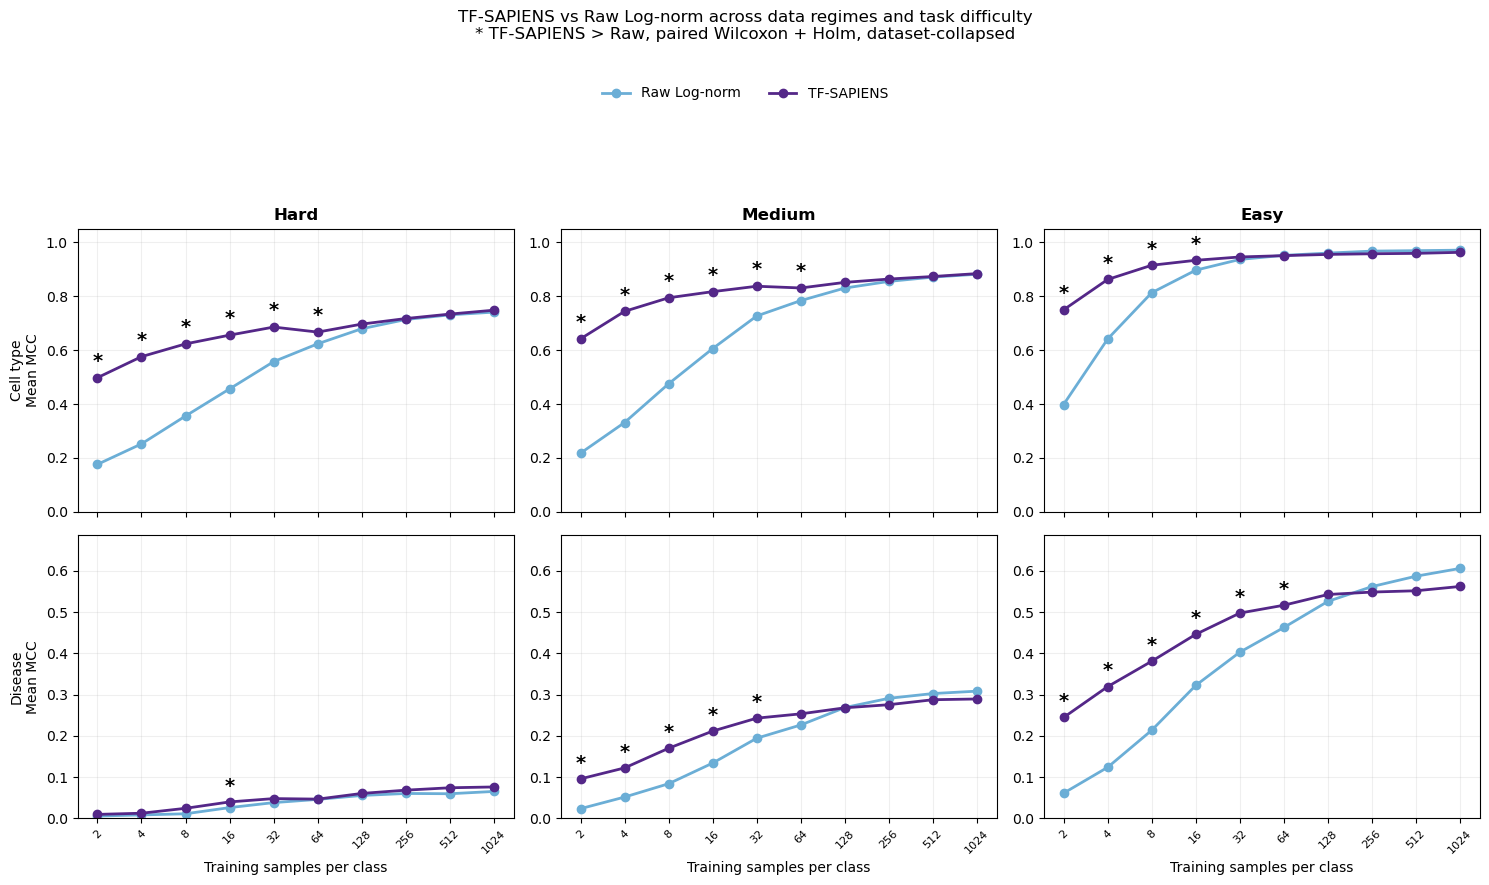

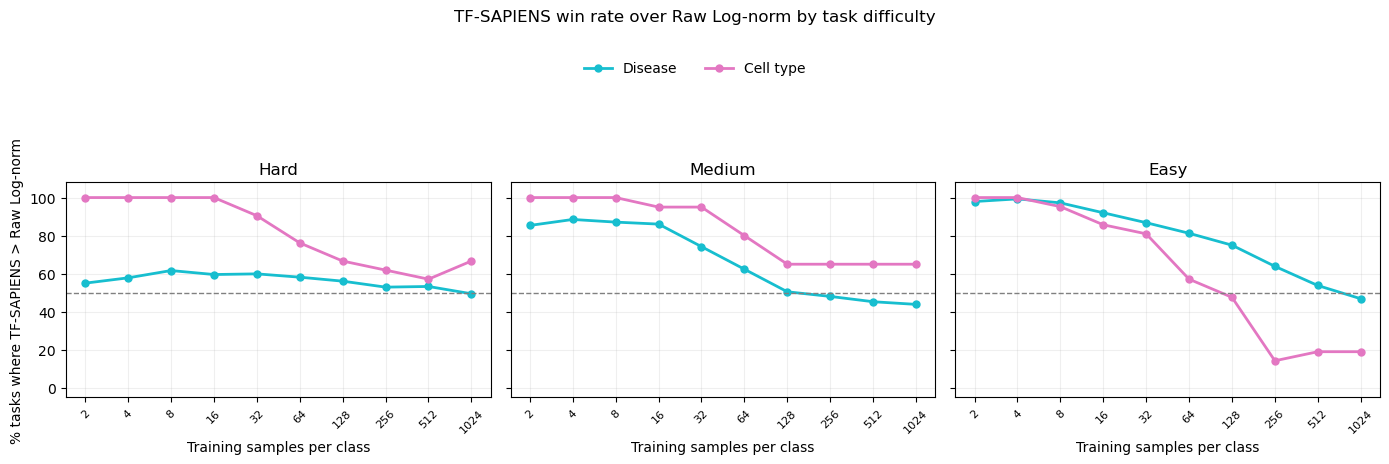

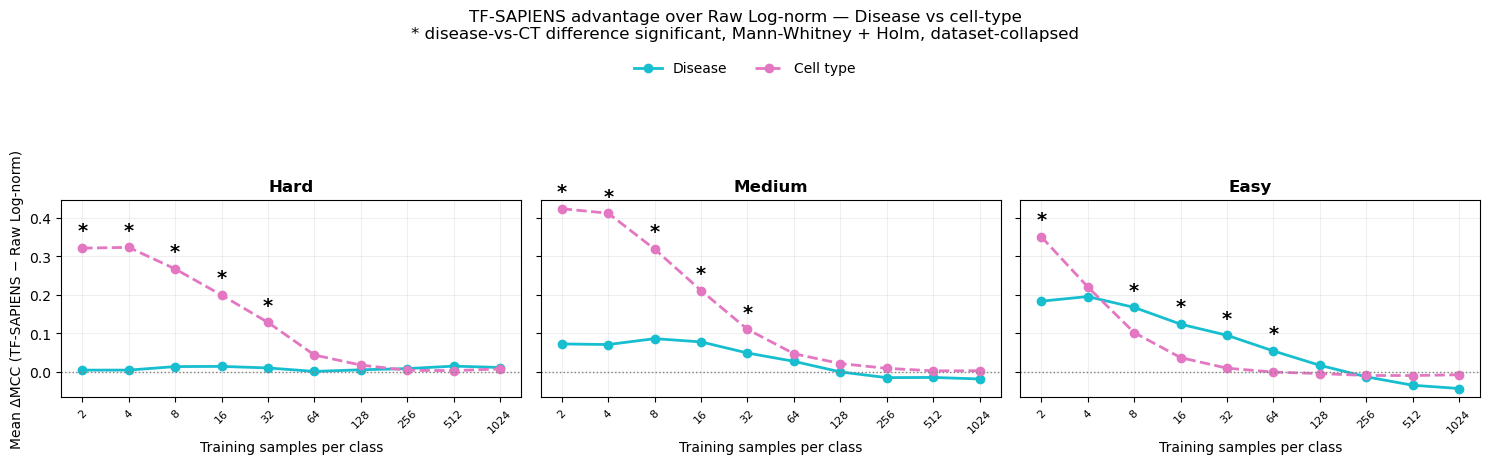


DONE. Key outputs:
  results_dataset_level.csv       <- use this for TF-vs-Raw significance
  results_tier_dataset_level.csv   <- use this for disease-vs-CT significance
  sensitivity_check_fig1_flips.csv           <- rows where correction changed the verdict
  sensitivity_check_fig3_flips.csv           <- same, for the disease-vs-CT comparison
  TF_vs_Raw_absolute_MCC_by_difficulty.png
  TF_advantage_disease_vs_celltype_by_difficulty.png


In [10]:
# ============================================================
# COMPLETE ANALYSIS — CSV load through corrected plots
#
# This is doc 6 + doc 7 combined, with the dataset-clustering
# correction (Wilcoxon TF-vs-Raw, and Mann-Whitney disease-vs-CT)
# applied to the significance stars in Figures 1 and 3.
#
# Figure 2 (win rate) is unchanged in substance — descriptive, no p-values.
#
# Plot fixes applied on top:
#   1) Raw Log-norm / TF-SAPIENS use feature_colors.get_color()
#   2) legend anchored below suptitle so it no longer collides with it
#   3) win-rate y-axis padded so 100%/0% lines don't collapse into the frame
#   4) Disease vs Cell-type comparisons (Fig 2 + Fig 3) use two colors
#      outside FEATURE_COLOR_MAP, since they compare benchmarks, not models
# ============================================================

from scipy.stats import wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from feature_colors import get_color, FEATURE_COLOR_MAP


# ============================================================
# 0. LOAD RESULTS CSVs — adjust paths to your actual files
# ============================================================

disease_full  = df_standard.copy()
celltype_full = df_celltype_standard.copy()
disease_low   = df_disease_low.copy()
celltype_low  = df_celltype_low.copy()


# ============================================================
# 1. SETTINGS
# ============================================================

MODEL = "TF-SAPIENS"
RAW = "Raw Log-norm"
BASELINES = ["PCA-50", "Raw Log-norm"]
TIERS = ["Hard", "Medium", "Easy"]
N_VALUES = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

# Colors for Disease vs Cell-type comparisons (Fig 2, Fig 3) — these compare
# BENCHMARKS, not models, so they deliberately sit outside FEATURE_COLOR_MAP
# (whose blues/greens/reds/purples/gray are all reserved for specific methods).
BENCHMARK_COLORS = {"Disease": "#17becf", "Cell type": "#e377c2"}


# ============================================================
# 2. CLEAN DATA
# ============================================================

def clean_results(df):
    df = df.copy()
    if "error" in df.columns:
        df = df[df["error"].isna()]
    if "skip_reason" in df.columns:
        df = df[df["skip_reason"].isna()]
    df = df[df["MCC"].notna()].copy()
    return df

disease_full  = clean_results(disease_full)
celltype_full = clean_results(celltype_full)
disease_low   = clean_results(disease_low)
celltype_low  = clean_results(celltype_low)


# ============================================================
# 3. DEFINE TASK IDs
# ============================================================

# Disease: one task = dataset_id x cell_type
if "task_id" not in disease_full.columns:
    disease_full["task_id"] = (
        disease_full["dataset_id"].astype(str) + "::" + disease_full["cell_type"].astype(str)
    )
if "task_id" not in disease_low.columns:
    disease_low["task_id"] = (
        disease_low["dataset_id"].astype(str) + "::" + disease_low["cell_type"].astype(str)
    )

# Cell type: one task = dataset
celltype_full["task_id"] = celltype_full["dataset_id"].astype(str)
celltype_low["task_id"]  = celltype_low["dataset_id"].astype(str)


# ============================================================
# 4. DIFFICULTY = mean full-data MCC of PCA-50 + Raw Log-norm
# ============================================================

def make_difficulty_table(df, task_col):
    task_method = (
        df[df["feature_clean"].isin(BASELINES)]
        .groupby([task_col, "feature_clean"])["MCC"]
        .mean()
        .unstack("feature_clean")
    )
    task_method = task_method[BASELINES].dropna()
    task_method["difficulty_score"] = task_method[BASELINES].mean(axis=1)

    q1, q2 = task_method["difficulty_score"].quantile([1/3, 2/3])
    task_method["difficulty_tier"] = pd.cut(
        task_method["difficulty_score"],
        bins=[-np.inf, q1, q2, np.inf],
        labels=TIERS,
        include_lowest=True,
    )
    return task_method.reset_index(), q1, q2

difficulty_disease, q1_dis, q2_dis = make_difficulty_table(disease_full, task_col="task_id")
difficulty_disease[["dataset_id", "cell_type"]] = (
    difficulty_disease["task_id"].str.split("::", n=1, expand=True)
)

difficulty_ct, q1_ct, q2_ct = make_difficulty_table(celltype_full, task_col="task_id")
difficulty_ct = difficulty_ct.rename(columns={"task_id": "dataset_id"})

print("DISEASE tier boundaries:", q1_dis, q2_dis)
print(difficulty_disease["difficulty_tier"].value_counts().reindex(TIERS))
print("\nCELL TYPE tier boundaries:", q1_ct, q2_ct)
print(difficulty_ct["difficulty_tier"].value_counts().reindex(TIERS))


# ============================================================
# 5. MERGE DIFFICULTY ONTO LOW-DATA RESULTS (fixed across n)
# ============================================================

disease_low = disease_low.merge(
    difficulty_disease[["task_id", "difficulty_score", "difficulty_tier"]].drop_duplicates("task_id"),
    on="task_id", how="inner",
)
celltype_low = celltype_low.merge(
    difficulty_ct[["dataset_id", "difficulty_score", "difficulty_tier"]].drop_duplicates("dataset_id"),
    on="dataset_id", how="inner",
)


# ============================================================
# 6. PAIRED PERFORMANCE HELPERS
# ============================================================

def get_paired_performance(df, n, tier, task_col):
    """Task-level TF/Raw pairs (used for original, uncorrected results)."""
    x = df[
        (df["n_per_class"] == n)
        & (df["difficulty_tier"] == tier)
        & (df["feature_clean"].isin([RAW, MODEL]))
    ].copy()
    perf = x.groupby([task_col, "feature_clean"])["MCC"].mean().unstack("feature_clean")
    if RAW not in perf.columns or MODEL not in perf.columns:
        return pd.DataFrame()
    return perf[[RAW, MODEL]].dropna()


def get_paired_performance_with_dataset(df, n, tier, task_col, dataset_col="dataset_id"):
    """Same, but keeps dataset_id attached so results can be collapsed to
    dataset level before testing (fixes the ICC~0.7 clustering issue)."""
    x = df[
        (df["n_per_class"] == n)
        & (df["difficulty_tier"] == tier)
        & (df["feature_clean"].isin([RAW, MODEL]))
    ].copy()

    group_cols = [task_col] if task_col == dataset_col else [task_col, dataset_col]
    perf = x.groupby(group_cols + ["feature_clean"])["MCC"].mean().unstack("feature_clean")

    if RAW not in perf.columns or MODEL not in perf.columns:
        return pd.DataFrame()

    perf = perf[[RAW, MODEL]].dropna().reset_index()
    if task_col == dataset_col:
        perf[dataset_col] = perf[task_col]
    return perf  # columns: task_col, dataset_col, RAW, MODEL


# ============================================================
# 7A. ORIGINAL (task-level) TF vs Raw per benchmark x tier x n
#     -> results  (uncorrected; kept for the sensitivity comparison)
# ============================================================

rows = []
for benchmark, df, task_col in [("Disease", disease_low, "task_id"),
                                 ("Cell type", celltype_low, "dataset_id")]:
    for tier in TIERS:
        for n in N_VALUES:
            perf = get_paired_performance(df=df, n=n, tier=tier, task_col=task_col)
            if len(perf) == 0:
                continue
            delta = perf[MODEL] - perf[RAW]
            try:
                if np.allclose(delta.values, 0):
                    p = 1.0
                else:
                    _, p = wilcoxon(perf[MODEL], perf[RAW], alternative="greater")
            except ValueError:
                p = np.nan
            rows.append({
                "benchmark": benchmark, "tier": tier, "n_per_class": n,
                "n_tasks": len(perf),
                "raw_mean": perf[RAW].mean(), "tf_mean": perf[MODEL].mean(),
                "delta_mean": delta.mean(), "delta_median": delta.median(),
                "win_rate": (delta > 0).mean() * 100,
                "p_raw": p,
            })

results = pd.DataFrame(rows)
results["p_holm"] = np.nan
for (benchmark, tier), g in results.groupby(["benchmark", "tier"]):
    idx = g.index[g["p_raw"].notna()]
    if len(idx) > 0:
        results.loc[idx, "p_holm"] = multipletests(results.loc[idx, "p_raw"], method="holm")[1]
results["significant"] = results["p_holm"] < 0.05


# ============================================================
# 7B. CORRECTED (dataset-collapsed) TF vs Raw per benchmark x tier x n
#     -> results_dataset  (this is what fixes #2)
# ============================================================

rows_dataset = []
for benchmark, df, task_col, dataset_col in [
    ("Disease", disease_low, "task_id", "dataset_id"),
    ("Cell type", celltype_low, "dataset_id", "dataset_id"),
]:
    for tier in TIERS:
        for n in N_VALUES:
            perf = get_paired_performance_with_dataset(
                df=df, n=n, tier=tier, task_col=task_col, dataset_col=dataset_col,
            )
            if len(perf) == 0:
                continue
            perf["delta"] = perf[MODEL] - perf[RAW]

            dataset_delta = perf.groupby(dataset_col)["delta"].mean()
            dataset_raw   = perf.groupby(dataset_col)[RAW].mean()
            dataset_tf    = perf.groupby(dataset_col)[MODEL].mean()
            n_datasets = len(dataset_delta)

            try:
                if np.allclose(dataset_delta.values, 0):
                    p = 1.0
                elif n_datasets < 2:
                    p = np.nan
                else:
                    _, p = wilcoxon(dataset_tf.values, dataset_raw.values, alternative="greater")
            except ValueError:
                p = np.nan

            rows_dataset.append({
                "benchmark": benchmark, "tier": tier, "n_per_class": n,
                "n_tasks": len(perf), "n_datasets": n_datasets,
                "raw_mean": dataset_raw.mean(), "tf_mean": dataset_tf.mean(),
                "delta_mean": dataset_delta.mean(), "delta_median": dataset_delta.median(),
                "win_rate_dataset": (dataset_delta > 0).mean() * 100,
                "p_raw": p,
            })

results_dataset = pd.DataFrame(rows_dataset)
results_dataset["p_holm"] = np.nan
for (benchmark, tier), g in results_dataset.groupby(["benchmark", "tier"]):
    idx = g.index[g["p_raw"].notna()]
    if len(idx) > 0:
        results_dataset.loc[idx, "p_holm"] = multipletests(
            results_dataset.loc[idx, "p_raw"], method="holm")[1]
results_dataset["significant"] = results_dataset["p_holm"] < 0.05

# Sensitivity check: which task-level "significant" calls don't survive?
comparison = results.merge(
    results_dataset[["benchmark", "tier", "n_per_class", "n_datasets", "significant"]],
    on=["benchmark", "tier", "n_per_class"], suffixes=("_task", "_dataset"),
)
comparison["flipped"] = comparison["significant_task"] != comparison["significant_dataset"]
print("\n=== #2 sensitivity: TF-vs-Raw significance flips after dataset collapse ===")
print(comparison[comparison["flipped"]][
    ["benchmark", "tier", "n_per_class", "n_datasets", "delta_mean_task" if "delta_mean_task" in comparison else "delta_mean", "significant_task", "significant_dataset"]
])


# ============================================================
# 8A. ORIGINAL (task-level) disease-vs-CT Mann-Whitney per tier x n
#     -> results_tier (uncorrected)
# ============================================================

compare_rows = []
for tier in TIERS:
    for n in N_VALUES:
        perf_dis = get_paired_performance(df=disease_low, n=n, tier=tier, task_col="task_id")
        perf_ct  = get_paired_performance(df=celltype_low, n=n, tier=tier, task_col="dataset_id")
        if len(perf_dis) == 0 or len(perf_ct) == 0:
            continue
        delta_dis = perf_dis[MODEL] - perf_dis[RAW]
        delta_ct  = perf_ct[MODEL] - perf_ct[RAW]
        U, p = mannwhitneyu(delta_dis, delta_ct, alternative="two-sided")
        compare_rows.append({
            "tier": tier, "n_per_class": n,
            "n_disease": len(delta_dis), "n_celltype": len(delta_ct),
            "mean_disease": delta_dis.mean(), "mean_celltype": delta_ct.mean(),
            "difference_of_means": delta_dis.mean() - delta_ct.mean(),
            "U": U, "p_raw": p,
        })

results_tier = pd.DataFrame(compare_rows)
results_tier["p_holm"] = np.nan
for tier in TIERS:
    idx = (results_tier["tier"] == tier) & results_tier["p_raw"].notna()
    if idx.sum() > 0:
        results_tier.loc[idx, "p_holm"] = multipletests(
            results_tier.loc[idx, "p_raw"], method="holm")[1]
results_tier["significant"] = results_tier["p_holm"] < 0.05


# ============================================================
# 8B. CORRECTED (dataset-collapsed) disease-vs-CT Mann-Whitney
#     -> results_tier_dataset  (this is what fixes #1)
# ============================================================

compare_rows_ds = []
for tier in TIERS:
    for n in N_VALUES:
        perf_dis = get_paired_performance_with_dataset(
            df=disease_low, n=n, tier=tier, task_col="task_id", dataset_col="dataset_id")
        if len(perf_dis) == 0:
            continue
        perf_dis["delta"] = perf_dis[MODEL] - perf_dis[RAW]
        delta_dis = perf_dis.groupby("dataset_id")["delta"].mean()  # collapsed

        perf_ct = get_paired_performance_with_dataset(
            df=celltype_low, n=n, tier=tier, task_col="dataset_id", dataset_col="dataset_id")
        if len(perf_ct) == 0:
            continue
        perf_ct["delta"] = perf_ct[MODEL] - perf_ct[RAW]
        delta_ct = perf_ct.groupby("dataset_id")["delta"].mean()  # no-op for CT

        if len(delta_dis) < 2 or len(delta_ct) < 2:
            continue

        U, p = mannwhitneyu(delta_dis, delta_ct, alternative="two-sided")
        compare_rows_ds.append({
            "tier": tier, "n_per_class": n,
            "n_disease_datasets": len(delta_dis), "n_celltype_datasets": len(delta_ct),
            "mean_disease": delta_dis.mean(), "mean_celltype": delta_ct.mean(),
            "difference_of_means": delta_dis.mean() - delta_ct.mean(),
            "U": U, "p_raw": p,
        })

results_tier_dataset = pd.DataFrame(compare_rows_ds)
results_tier_dataset["p_holm"] = np.nan
for tier in TIERS:
    idx = (results_tier_dataset["tier"] == tier) & results_tier_dataset["p_raw"].notna()
    if idx.sum() > 0:
        results_tier_dataset.loc[idx, "p_holm"] = multipletests(
            results_tier_dataset.loc[idx, "p_raw"], method="holm")[1]
results_tier_dataset["significant"] = results_tier_dataset["p_holm"] < 0.05

# ============================================================
# Full dataset-level disease-vs-CT table (not just flips) — Easy tier
# ============================================================
print("\n=== #1 FULL: disease-vs-CT delta comparison, dataset-collapsed, Easy tier ===")
print(
    results_tier_dataset[results_tier_dataset["tier"] == "Easy"][
        ["n_per_class", "n_disease_datasets", "n_celltype_datasets",
         "mean_disease", "mean_celltype", "difference_of_means",
         "p_raw", "p_holm", "significant"]
    ].sort_values("n_per_class").round(4).to_string(index=False)
)


comparison_fig3 = results_tier.merge(
    results_tier_dataset[["tier", "n_per_class", "n_disease_datasets", "significant"]],
    on=["tier", "n_per_class"], suffixes=("_task", "_dataset"),
)
comparison_fig3["flipped"] = comparison_fig3["significant_task"] != comparison_fig3["significant_dataset"]
print("\n=== #1 sensitivity: disease-vs-CT significance flips after dataset collapse ===")
print(comparison_fig3[comparison_fig3["flipped"]])


# ============================================================
# 9. FIGURE 1 (CORRECTED) — absolute MCC, stars from results_dataset
#    Fix 1: feature colors from feature_colors.py
#    Fix 2: legend anchored below suptitle, no collision
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
benchmark_rows = [("Cell type", 0), ("Disease", 1)]

for benchmark, row_i in benchmark_rows:
    r_all = results_dataset[results_dataset["benchmark"] == benchmark]
    ymax_global = max(r_all["raw_mean"].max(), r_all["tf_mean"].max())
    row_ylim = (0, min(1.05, ymax_global + 0.08)) if benchmark == "Cell type" else (0, ymax_global + 0.08)

    for col_i, tier in enumerate(TIERS):
        ax = axes[row_i, col_i]

        r = results_dataset[
            (results_dataset["benchmark"] == benchmark) & (results_dataset["tier"] == tier)
        ].sort_values("n_per_class")

        # Fix 1: feature colors instead of matplotlib defaults
        ax.plot(r["n_per_class"], r["raw_mean"], marker="o", linewidth=2,
                 color=get_color(RAW), label="Raw Log-norm")
        ax.plot(r["n_per_class"], r["tf_mean"], marker="o", linewidth=2,
                 color=get_color(MODEL), label="TF-SAPIENS")

        sig = r[r["significant"]]
        for _, x in sig.iterrows():
            y = max(x["raw_mean"], x["tf_mean"])
            offset = 0.025 if benchmark == "Cell type" else 0.015
            ax.text(x["n_per_class"], y + offset, "*", ha="center", va="bottom",
                    fontsize=14, fontweight="bold")

        ax.set_xscale("log", base=2)
        ax.set_xticks(N_VALUES)
        ax.set_xticklabels(N_VALUES, rotation=45, fontsize=8)
        ax.set_ylim(row_ylim)
        ax.grid(alpha=0.2)
        if row_i == 0:
            ax.set_title(tier, fontsize=12, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel(f"{benchmark}\nMean MCC")
        if row_i == 1:
            ax.set_xlabel("Training samples per class")

# Fix 2: legend anchored explicitly, suptitle pushed above it, tight_layout given room
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.suptitle(
    "TF-SAPIENS vs Raw Log-norm across data regimes and task difficulty\n"
    "* TF-SAPIENS > Raw, paired Wilcoxon + Holm, dataset-collapsed",
    y=1.10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig("plots_brief/TF_vs_Raw_absolute_MCC_by_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 10. FIGURE 2 (unchanged in substance) — win rate, no p-values
#    Fix 3: y-axis padded so 100%/0% don't collapse into the frame
#    Fix 4: Disease/Cell-type use BENCHMARK_COLORS, not model colors
#    Fix 2: legend anchored below suptitle
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, tier in zip(axes, TIERS):
    r = results[results["tier"] == tier]
    for benchmark in ["Disease", "Cell type"]:
        d = r[r["benchmark"] == benchmark].sort_values("n_per_class")
        ax.plot(d["n_per_class"], d["win_rate"], color=BENCHMARK_COLORS[benchmark],
                 marker="o", linewidth=2, markersize=5, label=benchmark)
    ax.axhline(50, color="gray", linestyle="--", linewidth=1)
    ax.set_xscale("log", base=2)
    ax.set_xticks(N_VALUES)
    ax.set_xticklabels(N_VALUES, rotation=45, fontsize=8)
    # Fix 3: padded range so lines at 0%/100% don't merge with the plot border
    ax.set_ylim(-5, 108)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_title(tier)
    ax.set_xlabel("Training samples per class")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("% tasks where TF-SAPIENS > Raw Log-norm")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
fig.suptitle("TF-SAPIENS win rate over Raw Log-norm by task difficulty", y=1.15)
plt.tight_layout(rect=[0, 0, 1, 0.88])
#plt.savefig("plots_brief/TF_vs_Raw_winrate_by_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 11. FIGURE 3 — FM advantage, disease vs CT, stars from results_tier_dataset
#    Fix 4: Disease/Cell-type use BENCHMARK_COLORS, not model colors
#    Fix 2: legend anchored below suptitle
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, tier in zip(axes, TIERS):
    r = results_tier_dataset[results_tier_dataset["tier"] == tier].sort_values("n_per_class")

    ax.plot(r["n_per_class"], r["mean_disease"], marker="o", linewidth=2,
             color=BENCHMARK_COLORS["Disease"], label="Disease")
    ax.plot(r["n_per_class"], r["mean_celltype"], marker="o", linestyle="--", linewidth=2,
             color=BENCHMARK_COLORS["Cell type"], label="Cell type")
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_xscale("log", base=2)
    ax.set_xticks(N_VALUES)
    ax.set_xticklabels(N_VALUES, rotation=45, fontsize=8)
    ax.set_title(tier, fontsize=12, fontweight="bold")
    ax.set_xlabel("Training samples per class")
    ax.grid(alpha=0.2)

    sig = r[r["significant"]]
    for _, row in sig.iterrows():
        ymax = max(row["mean_disease"], row["mean_celltype"])
        ax.text(row["n_per_class"], ymax + 0.02, "*", ha="center", va="bottom",
                fontsize=14, fontweight="bold")

axes[0].set_ylabel(f"Mean \u0394MCC ({MODEL} \u2212 {RAW})")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
fig.suptitle(
    f"{MODEL} advantage over Raw Log-norm — Disease vs cell-type\n"
    "* disease-vs-CT difference significant, Mann-Whitney + Holm, dataset-collapsed",
    y=1.15,
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
#plt.savefig("plots_brief/TF_advantage_disease_vs_celltype_by_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 12. SAVE EVERYTHING
# ============================================================

print("\nDONE. Key outputs:")
print("  results_dataset_level.csv       <- use this for TF-vs-Raw significance")
print("  results_tier_dataset_level.csv   <- use this for disease-vs-CT significance")
print("  sensitivity_check_fig1_flips.csv           <- rows where correction changed the verdict")
print("  sensitivity_check_fig3_flips.csv           <- same, for the disease-vs-CT comparison")
print("  TF_vs_Raw_absolute_MCC_by_difficulty.png")
print("  TF_advantage_disease_vs_celltype_by_difficulty.png")

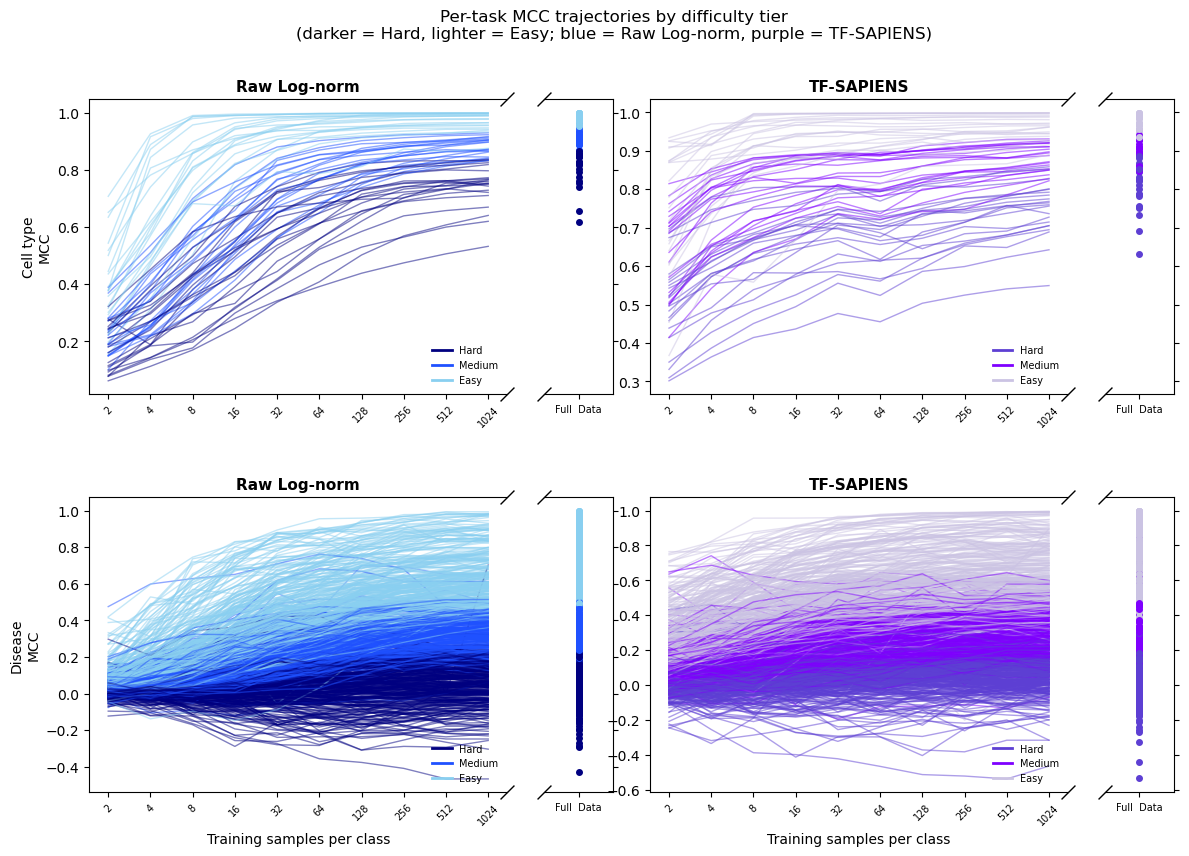

In [11]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import colorsys

# ============================================================
# Color shading: darker = Hard, lighter = Easy, per base color
# ============================================================

import colorsys

def adjust_lightness(hex_color, factor):
    """
    factor > 1 lightens, < 1 darkens, factor == 1 leaves unchanged.
    Works in HLS space so hue and saturation are preserved -- avoids the
    greyish look you get from scaling RGB linearly toward black/white.
    """
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return "#{:02x}{:02x}{:02x}".format(int(r * 255), int(g * 255), int(b * 255))


def tier_shades(base_color):
    return {
        "Hard":   adjust_lightness(base_color, 0.55),  # darker, saturated
        "Medium": adjust_lightness(base_color, 1.0),   # base color
        "Easy":   adjust_lightness(base_color, 1.55),  # lighter
    }

#RAW_SHADES = tier_shades(_BLUE_DARK)
#TF_SHADES  = tier_shades(_PURPLE_TF)
# Blue — Raw Log-norm
_BLUE_DARK  = "#000080"
_BLUE_MID   = "#1F51FF"
_BLUE_LIGHT = "#89CFF0"

# Purple — TF
_PURPLE_DARK  = "#5D3FD3"
_PURPLE_MID   = "#7F00FF"  # original
_PURPLE_LIGHT = "#CBC3E3"

RAW_SHADES = {"Hard": _BLUE_DARK,   "Medium": _BLUE_MID,   "Easy": _BLUE_LIGHT}
TF_SHADES  = {"Hard": _PURPLE_DARK, "Medium": _PURPLE_MID, "Easy": _PURPLE_LIGHT}

# ============================================================
# Draw one panel (main + standard broken-axis pair) into given axes
# ============================================================

def draw_task_lines_panel(ax1, ax2, df_low, df_full, difficulty_table, task_col,
                           feature, shades, full_data_label=2048,
                           line_alpha=0.5, line_width=1.0):
    low = df_low[df_low["feature_clean"] == feature].copy()
    low_agg = low.groupby([task_col, "n_per_class"])["MCC"].mean().reset_index()

    full = df_full[df_full["feature_clean"] == feature].copy()
    full_agg = (
        full.groupby(task_col)["MCC"].mean().reset_index()
        .rename(columns={"MCC": "MCC_standard"})
    )

    tier_lookup = difficulty_table[[task_col, "difficulty_tier"]].drop_duplicates(task_col)
    low_agg = low_agg.merge(tier_lookup, on=task_col, how="inner")
    full_agg = full_agg.merge(tier_lookup, on=task_col, how="inner")

    for tid, g in low_agg.groupby(task_col):
        g = g.sort_values("n_per_class")
        tier = g["difficulty_tier"].iloc[0]
        ax1.plot(g["n_per_class"], g["MCC"],
                  color=shades.get(tier, "#999999"),
                  alpha=line_alpha, linewidth=line_width)

    for tid, row in full_agg.set_index(task_col).iterrows():
        tier = row["difficulty_tier"]
        ax2.plot(full_data_label, row["MCC_standard"],
                  marker="o", markersize=4,
                  color=shades.get(tier, "#999999"), alpha=1.0)  # <-- full opacity

    ax1.set_xscale("log", base=2)
    ax1.set_xticks(N_VALUES)
    ax1.set_xticklabels(N_VALUES, rotation=45, fontsize=7)
    ax1.spines["right"].set_visible(False)

    ax2.set_xticks([full_data_label])
    ax2.set_xticklabels(["Full  Data"], fontsize=7)
    ax2.tick_params(axis="y", labelleft=False)
    ax2.spines["left"].set_visible(False)
    ax2.yaxis.tick_right()

    kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=10,
                  linestyle="none", color="k", mec="k", mew=1, clip_on=False)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)

# ============================================================
# Assemble 2x2 figure: rows = benchmark, cols = feature
# (0,0)=Raw/celltype  (0,1)=TF/celltype
# (1,0)=Raw/disease   (1,1)=TF/disease
# ============================================================

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)

panels = [
    # (row, df_low, df_full, difficulty_table, task_col, benchmark_label, col, feature, shades, feature_label)
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nMCC" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task MCC trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_MCC_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

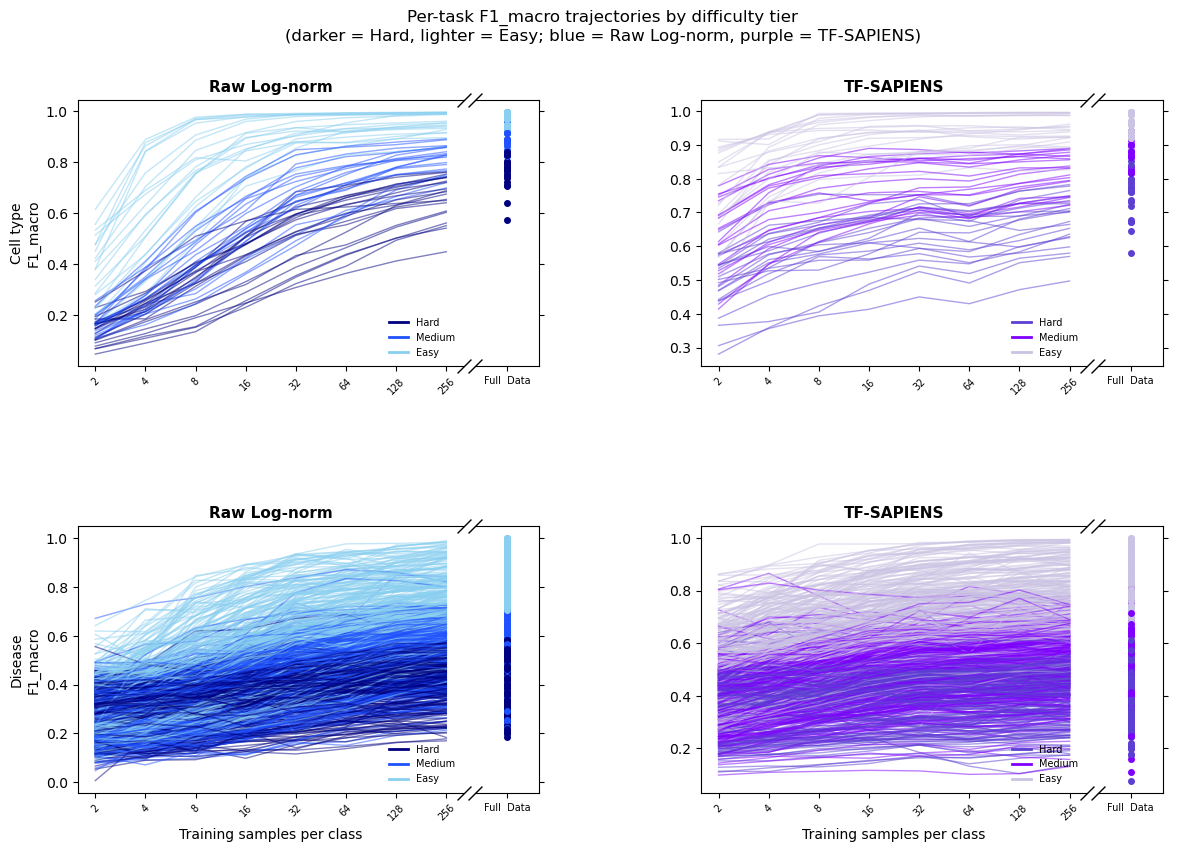

In [12]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import colorsys

# ============================================================
# Color shading: darker = Hard, lighter = Easy, per base color
# ============================================================

import colorsys

def adjust_lightness(hex_color, factor):
    """
    factor > 1 lightens, < 1 darkens, factor == 1 leaves unchanged.
    Works in HLS space so hue and saturation are preserved -- avoids the
    greyish look you get from scaling RGB linearly toward black/white.
    """
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return "#{:02x}{:02x}{:02x}".format(int(r * 255), int(g * 255), int(b * 255))


def tier_shades(base_color):
    return {
        "Hard":   adjust_lightness(base_color, 0.55),  # darker, saturated
        "Medium": adjust_lightness(base_color, 1.0),   # base color
        "Easy":   adjust_lightness(base_color, 1.55),  # lighter
    }

#RAW_SHADES = tier_shades(_BLUE_DARK)
#TF_SHADES  = tier_shades(_PURPLE_TF)
# Blue — Raw Log-norm
_BLUE_DARK  = "#000080"
_BLUE_MID   = "#1F51FF"
_BLUE_LIGHT = "#89CFF0"

# Purple — TF
_PURPLE_DARK  = "#5D3FD3"
_PURPLE_MID   = "#7F00FF"  # original
_PURPLE_LIGHT = "#CBC3E3"

RAW_SHADES = {"Hard": _BLUE_DARK,   "Medium": _BLUE_MID,   "Easy": _BLUE_LIGHT}
TF_SHADES  = {"Hard": _PURPLE_DARK, "Medium": _PURPLE_MID, "Easy": _PURPLE_LIGHT}

# ============================================================
# Draw one panel (main + standard broken-axis pair) into given axes
# ============================================================

def draw_task_lines_panel(ax1, ax2, df_low, df_full, difficulty_table, task_col,
                           feature, shades, full_data_label=2048,
                           line_alpha=0.5, line_width=1.0,
                           exclude_n=(512, 1024)):          # <-- new param
    low = df_low[df_low["feature_clean"] == feature].copy()
    low = low[~low["n_per_class"].isin(exclude_n)]          # <-- drop 512/1024
    low_agg = low.groupby([task_col, "n_per_class"])["F1_macro"].mean().reset_index()

    full = df_full[df_full["feature_clean"] == feature].copy()
    full_agg = (
        full.groupby(task_col)["F1_macro"].mean().reset_index()
        .rename(columns={"F1_macro": "F1_macro_standard"})
    )

    tier_lookup = difficulty_table[[task_col, "difficulty_tier"]].drop_duplicates(task_col)
    low_agg = low_agg.merge(tier_lookup, on=task_col, how="inner")
    full_agg = full_agg.merge(tier_lookup, on=task_col, how="inner")

    for tid, g in low_agg.groupby(task_col):
        g = g.sort_values("n_per_class")
        tier = g["difficulty_tier"].iloc[0]
        ax1.plot(g["n_per_class"], g["F1_macro"],
                  color=shades.get(tier, "#999999"),
                  alpha=line_alpha, linewidth=line_width)

    for tid, row in full_agg.set_index(task_col).iterrows():
        tier = row["difficulty_tier"]
        ax2.plot(full_data_label, row["F1_macro_standard"],
                  marker="o", markersize=4,
                  color=shades.get(tier, "#999999"), alpha=1.0)

    xticks_shown = [n for n in N_VALUES if n not in exclude_n]  # <-- filtered ticks
    ax1.set_xscale("log", base=2)
    ax1.set_xticks(xticks_shown)
    ax1.set_xticklabels(xticks_shown, rotation=45, fontsize=7)
    ax1.spines["right"].set_visible(False)

    ax2.set_xticks([full_data_label])
    ax2.set_xticklabels(["Full  Data"], fontsize=7)
    ax2.tick_params(axis="y", labelleft=False)
    ax2.spines["left"].set_visible(False)
    ax2.yaxis.tick_right()

    kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=10,
                  linestyle="none", color="k", mec="k", mew=1, clip_on=False)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
# ============================================================
# Assemble 2x2 figure: rows = benchmark, cols = feature
# (0,0)=Raw/celltype  (0,1)=TF/celltype
# (1,0)=Raw/disease   (1,1)=TF/disease
# ============================================================

from matplotlib.gridspec import GridSpecFromSubplotSpec

fig = plt.figure(figsize=(14, 9))
outer_gs = GridSpec(2, 2, figure=fig, hspace=0.6, wspace=0.35)  # spacing BETWEEN pairs only

panels = [
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 1, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   1, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    inner_gs = GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[3, 0.5],
        wspace=0.05,   # <-- tight gap between 256 and Full Data, independent of outer wspace
    )
    ax1 = fig.add_subplot(inner_gs[0, 0])
    ax2 = fig.add_subplot(inner_gs[0, 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

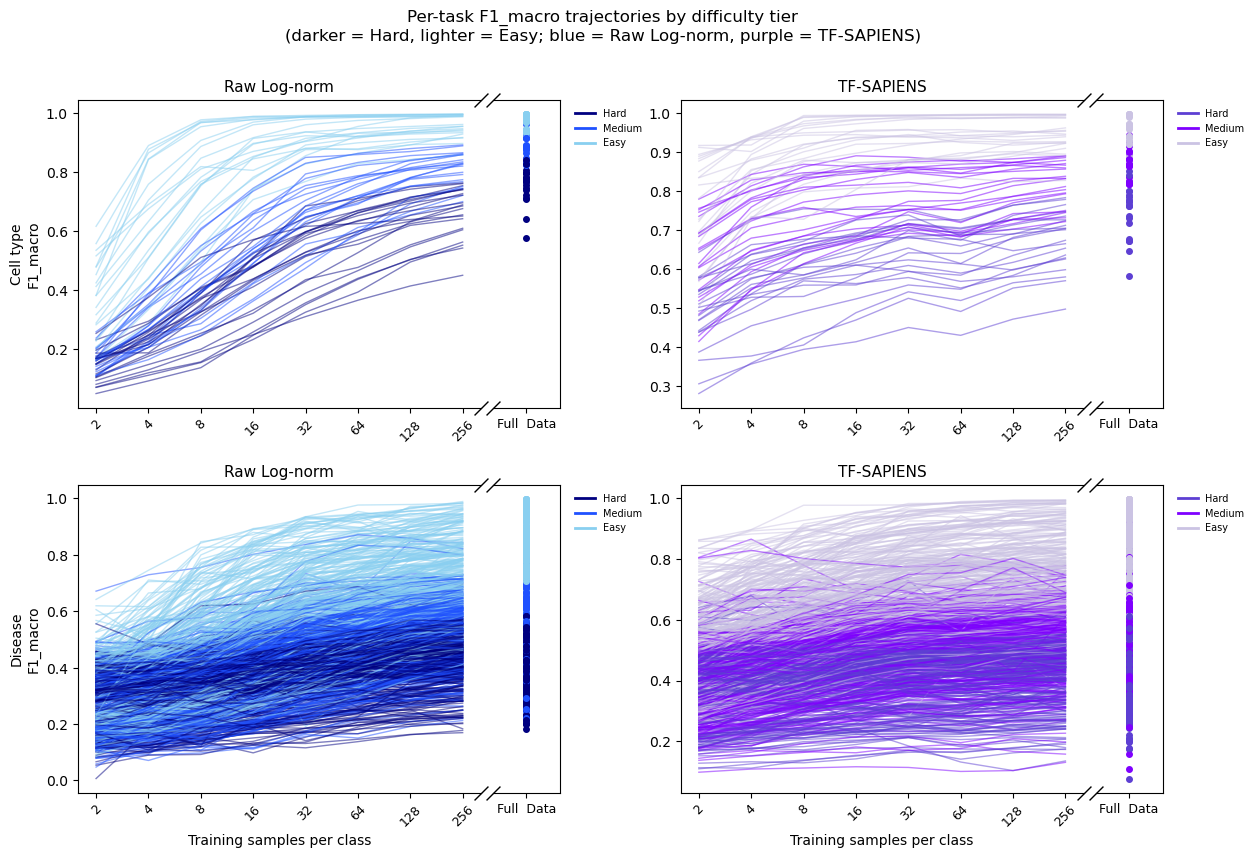

In [20]:
def draw_task_lines_panel(ax1, ax2, df_low, df_full, difficulty_table, task_col,
                           feature, shades, full_data_label=2048,
                           line_alpha=0.5, line_width=1.0,
                           exclude_n=(512, 1024)):
    low = df_low[df_low["feature_clean"] == feature].copy()
    low = low[~low["n_per_class"].isin(exclude_n)]
    low_agg = low.groupby([task_col, "n_per_class"])["F1_macro"].mean().reset_index()

    full = df_full[df_full["feature_clean"] == feature].copy()
    full_agg = (
        full.groupby(task_col)["F1_macro"].mean().reset_index()
        .rename(columns={"F1_macro": "F1_macro_standard"})
    )

    tier_lookup = difficulty_table[[task_col, "difficulty_tier"]].drop_duplicates(task_col)
    low_agg = low_agg.merge(tier_lookup, on=task_col, how="inner")
    full_agg = full_agg.merge(tier_lookup, on=task_col, how="inner")

    for tid, g in low_agg.groupby(task_col):
        g = g.sort_values("n_per_class")
        tier = g["difficulty_tier"].iloc[0]
        ax1.plot(g["n_per_class"], g["F1_macro"],
                  color=shades.get(tier, "#999999"),
                  alpha=line_alpha, linewidth=line_width)

    for tid, row in full_agg.set_index(task_col).iterrows():
        tier = row["difficulty_tier"]
        ax2.plot(full_data_label, row["F1_macro_standard"],
                  marker="o", markersize=4,
                  color=shades.get(tier, "#999999"), alpha=1.0)

    xticks_shown = [n for n in N_VALUES if n not in exclude_n]
    ax1.set_xscale("log", base=2)
    ax1.set_xticks(xticks_shown)
    ax1.set_xticklabels(xticks_shown, rotation=45, fontsize=9)
    ax.tick_params(axis="y", left=False)

    ax1.spines["right"].set_visible(False)

    ax2.set_xticks([full_data_label])
    ax2.set_xticklabels(["Full  Data"], fontsize=9)
    ax2.tick_params(
            axis="y",
            left=False,
            labelleft=False,
        )
    ax2.spines["left"].set_visible(False)
    #ax2.yaxis.tick_right()

    kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=10,
                  linestyle="none", color="k", mec="k", mew=1, clip_on=False)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)


fig = plt.figure(figsize=(14, 9))
outer_gs = GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

panels = [
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low, celltype_full, difficulty_ct,      "dataset_id", "Cell type", 1, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low,  disease_full,  difficulty_disease, "task_id",    "Disease",   1, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    inner_gs = GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[3, 0.5], wspace=0.05,
    )
    ax1 = fig.add_subplot(inner_gs[0, 0])
    ax2 = fig.add_subplot(inner_gs[0, 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11)

    # Legend moved off the lines -- anchored to ax2 (the "Full Data" strip)
    # instead of sitting inside ax1 where it got covered by dense trajectories.
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax2.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.1, 1.0),
        fontsize=7,
        frameon=False,
    )

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

fig.subplots_adjust(right=0.90)

plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2_1632.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
nCT=['6a270451-b4d9-43e0-aa89-e33aac1ac74b',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e',
 'd6dfdef1-406d-4efb-808c-3c5eddbfe0cb',
 '7b20c613-9add-43d1-87e9-defd3d9b9f8c',
 'e40c6272-af77-4a10-9385-62a398884f27',
 'c7775e88-49bf-4ba2-a03b-93f00447c958',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1',
 '2a498ace-872a-4935-984b-1afa70fd9886',
 '4a5b00e0-1ba3-4fd4-af89-d3512eb20720',
 'ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3',
 '13b61a7d-5605-4948-ba48-02c588960143',
 '576f193c-75d0-4a11-bd25-8676587e6dc2',
 'dea717d4-7bc0-4e46-950f-fd7e1cc8df7d',
 'a12ccb9b-4fbe-457d-8590-ac78053259ef',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9',
 'de2c780c-1747-40bd-9ccf-9588ec186cee']
nDisease= ['6a270451-b4d9-43e0-aa89-e33aac1ac74b::myeloid cell',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::unknown',
 'd6dfdef1-406d-4efb-808c-3c5eddbfe0cb::brush cell',
 '7b20c613-9add-43d1-87e9-defd3d9b9f8c::fibroblast',
 'd6dfdef1-406d-4efb-808c-3c5eddbfe0cb::intestinal epithelial cell',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::enterocyte',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::natural killer cell',
 'e40c6272-af77-4a10-9385-62a398884f27::intestinal crypt stem cell of colon',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::monocyte',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::erythrocyte',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::memory B cell',
 'd6dfdef1-406d-4efb-808c-3c5eddbfe0cb::intestinal enteroendocrine cell',
 '6a270451-b4d9-43e0-aa89-e33aac1ac74b::mast cell',
 '6a270451-b4d9-43e0-aa89-e33aac1ac74b::B cell',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::IgG plasma cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::IgA plasma cell',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1::club cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::T follicular helper cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::plasmablast',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::effector memory CD4-positive, alpha-beta T cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::IgG plasma cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::erythroid progenitor cell, mammalian',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::IgM plasma cell',
 '2a498ace-872a-4935-984b-1afa70fd9886::mature NK T cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::CD34-positive, CD38-negative hematopoietic stem cell',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1::non-classical monocyte',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1::endothelial cell of lymphatic vessel',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1::smooth muscle cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::CD8-positive, alpha-beta T cell',
 '1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1::pulmonary artery endothelial cell',
 '4a5b00e0-1ba3-4fd4-af89-d3512eb20720::antibody secreting cell',
 'c7775e88-49bf-4ba2-a03b-93f00447c958::erythrocyte',
 'ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3::megakaryocyte-erythroid progenitor cell',
 '13b61a7d-5605-4948-ba48-02c588960143::CD8-positive, alpha-beta T cell',
 '576f193c-75d0-4a11-bd25-8676587e6dc2::neutrophil',
 'dea717d4-7bc0-4e46-950f-fd7e1cc8df7d::plasma cell',
 'a12ccb9b-4fbe-457d-8590-ac78053259ef::kidney loop of Henle thin ascending limb epithelial cell',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::fibroblast',
 'ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3::mucosal invariant T cell',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::capillary endothelial cell',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::endothelial cell of artery',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::pericyte',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::vascular associated smooth muscle cell',
 '9fcb0b73-c734-40a5-be9c-ace7eea401c9::plasmacytoid dendritic cell',
 '13b61a7d-5605-4948-ba48-02c588960143::multi-ciliated epithelial cell',
 '7bb64315-9e5a-41b9-9235-59acf9642a3e::type G enteroendocrine cell',
 'de2c780c-1747-40bd-9ccf-9588ec186cee::dendritic cell']

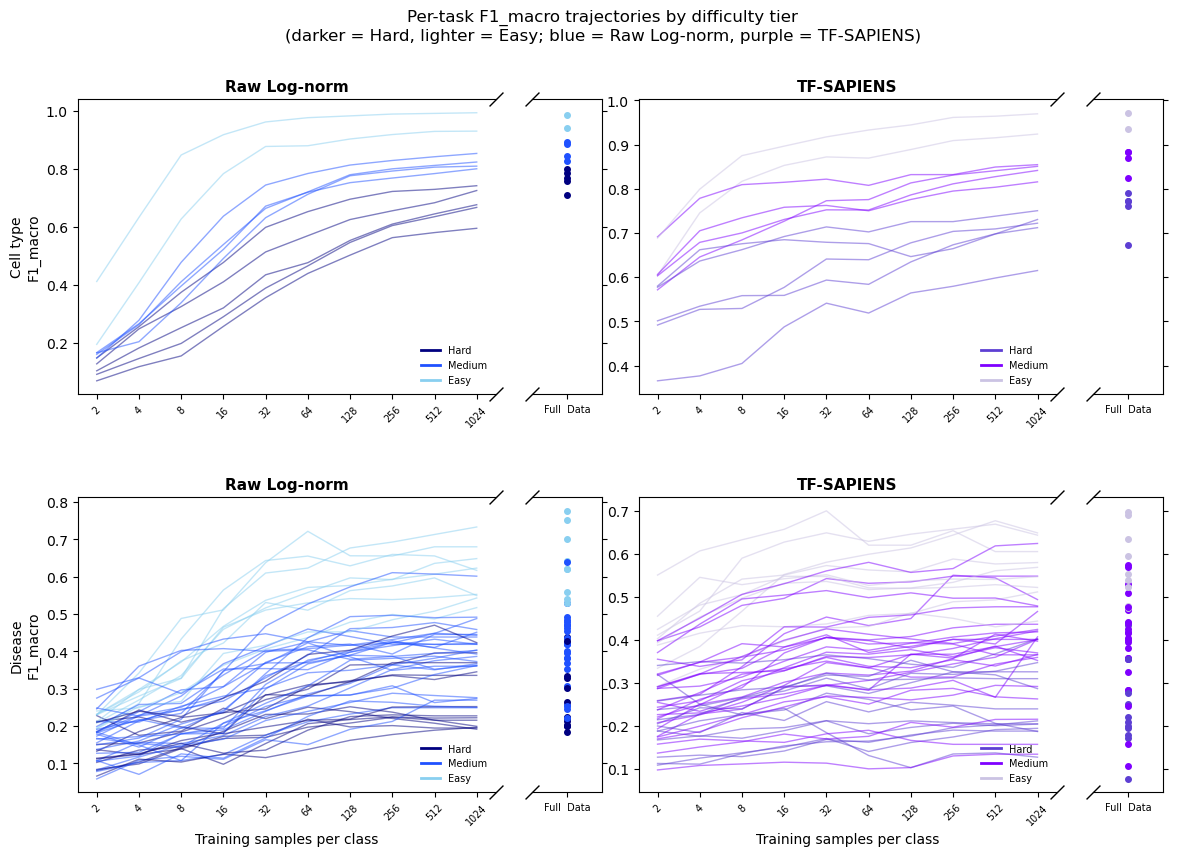

In [15]:

# ============================================================
# Assemble 2x2 figure: rows = benchmark, cols = feature
# (0,0)=Raw/celltype  (0,1)=TF/celltype
# (1,0)=Raw/disease   (1,1)=TF/disease
# ============================================================

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)
# Set the datasets you want to keep

def subset_by_datasets(df, dataset_ids, dataset_col="dataset_id"):
    return df[df[dataset_col].isin(dataset_ids)].copy()

celltype_low_sub   = subset_by_datasets(celltype_low, nCT)
celltype_full_sub  = subset_by_datasets(celltype_full, nCT)
difficulty_ct_sub  = subset_by_datasets(difficulty_ct, nCT)

disease_low_sub    = subset_by_datasets(disease_low, nDisease, dataset_col="task_id")
disease_full_sub   = subset_by_datasets(disease_full, nDisease, dataset_col="task_id")
difficulty_disease_sub = subset_by_datasets(difficulty_disease, nDisease, dataset_col="task_id")

panels = [
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

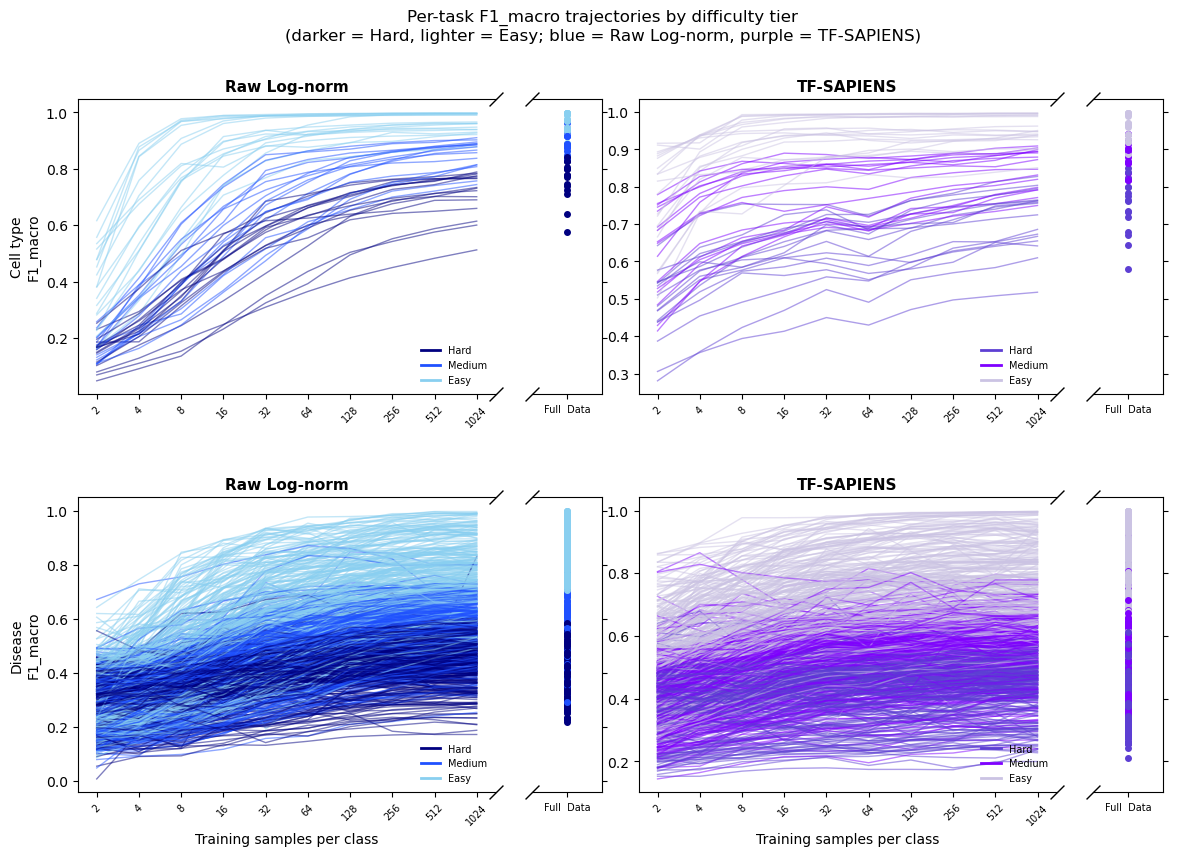

In [16]:

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)
# Set the datasets you want to keep

def subset_by_datasets(df, dataset_ids, dataset_col="dataset_id"):
    return df[~df[dataset_col].isin(dataset_ids)].copy()

celltype_low_sub   = subset_by_datasets(celltype_low, nCT)
celltype_full_sub  = subset_by_datasets(celltype_full, nCT)
difficulty_ct_sub  = subset_by_datasets(difficulty_ct, nCT)

disease_low_sub    = subset_by_datasets(disease_low, nDisease, dataset_col="task_id")
disease_full_sub   = subset_by_datasets(disease_full, nDisease, dataset_col="task_id")
difficulty_disease_sub = subset_by_datasets(difficulty_disease, nDisease, dataset_col="task_id")

panels = [
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
low = celltype_low[celltype_low["feature_clean"] == feature].copy()
low_agg = low.groupby(['dataset_id', "n_per_class"])["F1_macro"].mean().reset_index()
low_agg

,dataset_id,n_per_class,F1_macro
0,01ad3cd7-3929-4654-84c0-6db05bd5fd59,2.0,0.745516
1,01ad3cd7-3929-4654-84c0-6db05bd5fd59,4.0,0.802357
2,01ad3cd7-3929-4654-84c0-6db05bd5fd59,8.0,0.833871
3,01ad3cd7-3929-4654-84c0-6db05bd5fd59,16.0,0.842932
4,01ad3cd7-3929-4654-84c0-6db05bd5fd59,32.0,0.859497
...,...,...,...
615,fe4b89d5-461e-440c-a5a8-621b37b122c0,64.0,0.551217
616,fe4b89d5-461e-440c-a5a8-621b37b122c0,128.0,0.583318
617,fe4b89d5-461e-440c-a5a8-621b37b122c0,256.0,0.635728
618,fe4b89d5-461e-440c-a5a8-621b37b122c0,512.0,0.653381


In [18]:
tf_ct_wide = low_agg.pivot(index="dataset_id", columns="n_per_class", values="F1_macro")


In [19]:
# Get TF-SAPIENS cell-type low-data, one row per (dataset, n_per_class)
tf_ct = (
    celltype_low[celltype_low["feature_clean"] == MODEL]
    .groupby(["dataset_id", "n_per_class"])["MCC"]
    .mean()
    .reset_index()
)

# Pivot so each dataset is a row, each n_per_class a column
tf_ct_wide = tf_ct.pivot(index="dataset_id", columns="n_per_class", values="MCC")

# Compare n=16 against its neighbors n=8 and n=32
drop_from_8  = tf_ct_wide[8]  - tf_ct_wide[16]   # positive = dropped going INTO 16
drop_to_32   = tf_ct_wide[32] - tf_ct_wide[16]   # positive = recovered AFTER 16

dip_summary = pd.DataFrame({
    "F1_at_8":  tf_ct_wide[8],
    "F1_at_16": tf_ct_wide[16],
    "F1_at_32": tf_ct_wide[32],
    "drop_from_8":  drop_from_8,
    "recovery_to_32": drop_to_32,
}).sort_values("drop_from_8", ascending=False)

# Keep only the ones that actually dip AND recover -- a real V-shape, not just a decline
real_dips = dip_summary[
    (dip_summary["drop_from_8"] > 0.01) &      # dropped meaningfully going into 16
    (dip_summary["recovery_to_32"] > 0.01)     # and came back up after
]

print(f"{len(real_dips)} datasets show a V-shaped dip at n=16")
display(real_dips)

dip_dataset_ids = real_dips.index.tolist()
print(dip_dataset_ids)

1 datasets show a V-shaped dip at n=16


,F1_at_8,F1_at_16,F1_at_32,drop_from_8,recovery_to_32
dataset_id,,,,,
a199ca73-035d-44e2-9893-4c493151db21,0.831326,0.815468,0.842328,0.015858,0.026859


['a199ca73-035d-44e2-9893-4c493151db21']


In [20]:
c16= df_celltype_low.query('dataset_id.isin(@dip_dataset_ids)')

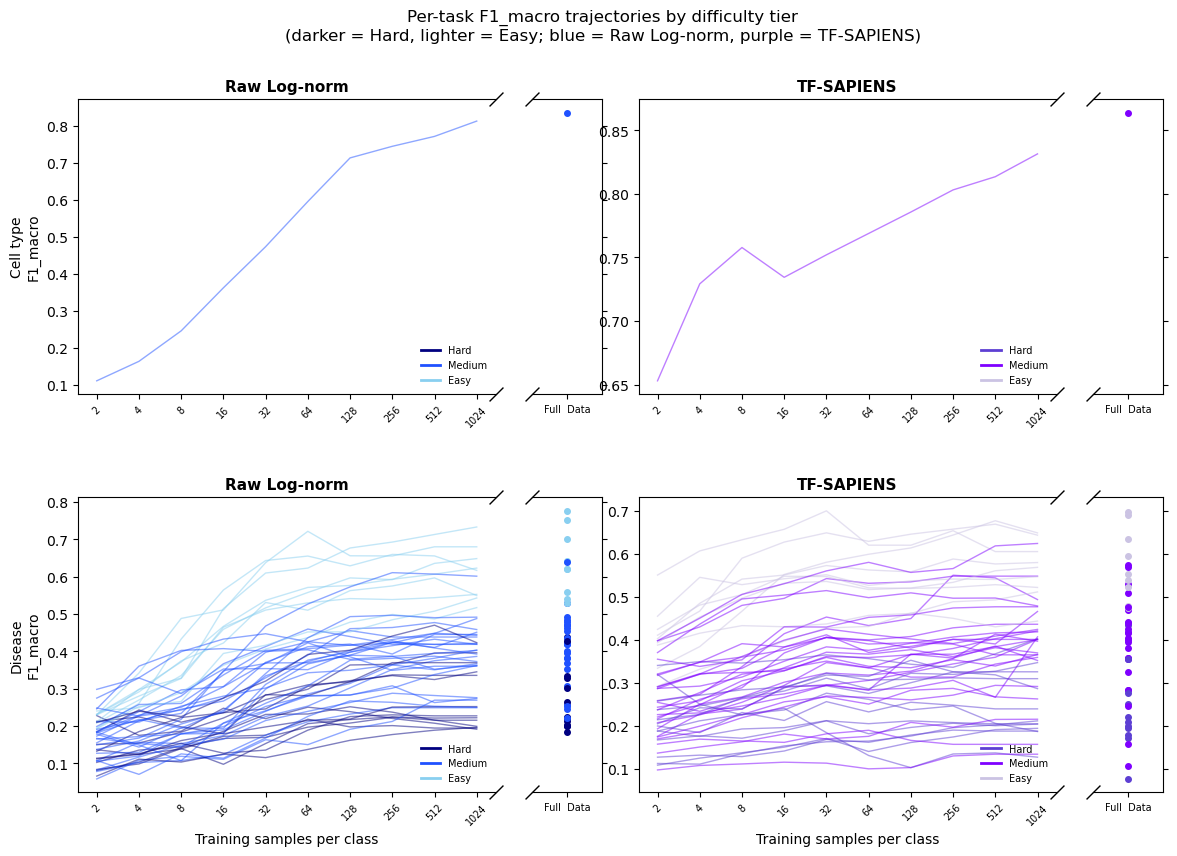

In [21]:

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)
# Set the datasets you want to keep

def subset_by_datasets(df, dataset_ids, dataset_col="dataset_id"):
    return df[df[dataset_col].isin(dataset_ids)].copy()

celltype_low_sub   = subset_by_datasets(celltype_low, dip_dataset_ids)
celltype_full_sub  = subset_by_datasets(celltype_full, dip_dataset_ids)
difficulty_ct_sub  = subset_by_datasets(difficulty_ct, dip_dataset_ids)

disease_low_sub    = subset_by_datasets(disease_low, nDisease, dataset_col="task_id")
disease_full_sub   = subset_by_datasets(disease_full, nDisease, dataset_col="task_id")
difficulty_disease_sub = subset_by_datasets(difficulty_disease, nDisease, dataset_col="task_id")

panels = [
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
c16[~c16.skip_reason.isna()]

,dataset_id,skip_reason,n_missing,fold,n_train,n_test,n_per_class,bootstrap,n_genes,n_cell_types,...,feature,donor_metric_error,AUROC,AUPRC,error,error_type,feature_clean,task_id,n_tasks,n_folds


In [23]:
lowestd=c16[(c16['dataset_id']=="3c75a463-6a87-4132-83a8-c3002624394d") &(c16['feature_clean'] == 'TF-SAPIENS')]

In [24]:
n_classes_celltype[n_classes_celltype.index=="3c75a463-6a87-4132-83a8-c3002624394d"]

NameError: name 'n_classes_celltype' is not defined

In [25]:
# Reconstruct whether early stopping would have been active, per task/n
def compute_early_stop_flag(n_per_class, n_classes, validation_fraction=0.1):
    len_y_train = n_per_class * n_classes  # assumes ceiling was met
    return len_y_train > (n_classes / validation_fraction)

celltype_tf = celltype_low[celltype_low["feature_clean"] == MODEL].copy()
celltype_tf["n_classes"] = celltype_tf["dataset_id"].map(n_classes_celltype)
celltype_tf["early_stop_active"] = compute_early_stop_flag(
    celltype_tf["n_per_class"], celltype_tf["n_classes"]
)

# Confirm: at n=8, always False; at n=16+, always True (should be near-universal)
celltype_tf.groupby("n_per_class")["early_stop_active"].mean()

NameError: name 'n_classes_celltype' is not defined

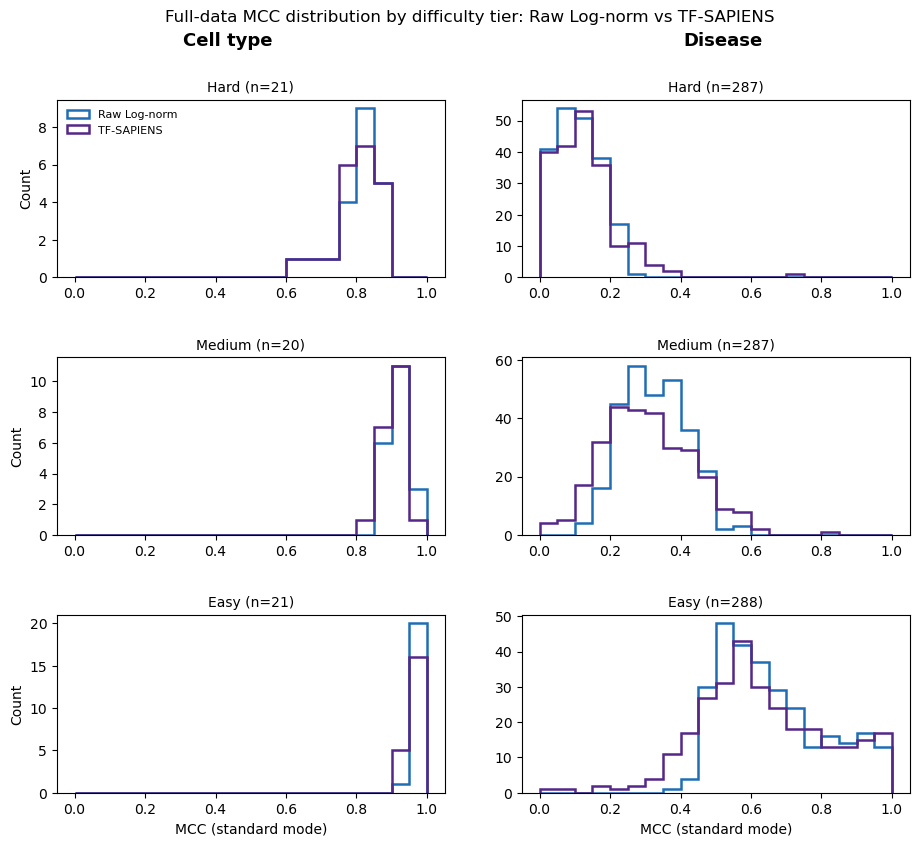

In [26]:
import matplotlib.pyplot as plt

_BLUE_DARK = "#1f6eb5"   # Raw Log-norm
_PURPLE_TF = "#542788"   # TF-SAPIENS


def get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, feature):
    """One MCC value per task (folds averaged), tagged with its tier."""
    df = df_full[df_full["feature_clean"] == feature].copy()
    task_mcc = df.groupby(task_col)["MCC"].mean().reset_index()
    tier_lookup = difficulty_table[[task_col, "difficulty_tier"]].drop_duplicates(task_col)
    return task_mcc.merge(tier_lookup, on=task_col, how="inner")


def plot_mcc_hist_by_tier(fig, gs, col, df_full, difficulty_table, task_col,
                           benchmark_label, bins=20):
    raw_data = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, RAW)
    tf_data  = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, MODEL)

    for row, tier in enumerate(TIERS):
        ax = fig.add_subplot(gs[row, col])

        raw_vals = raw_data.loc[raw_data["difficulty_tier"] == tier, "MCC"]
        tf_vals  = tf_data.loc[tf_data["difficulty_tier"] == tier, "MCC"]

        ax.hist(raw_vals, bins=bins, range=(0, 1), color=_BLUE_DARK,
                histtype="step", linewidth=1.8, label="Raw Log-norm")
        ax.hist(tf_vals, bins=bins, range=(0, 1), color=_PURPLE_TF,
                histtype="step", linewidth=1.8, label="TF-SAPIENS")

        ax.set_title(f"{tier} (n={len(raw_vals)})", fontsize=10)
        if col == 0:
            ax.set_ylabel("Count")
        if row == 2:
            ax.set_xlabel("MCC (standard mode)")
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)


fig = plt.figure(figsize=(11, 9))
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.2)

plot_mcc_hist_by_tier(fig, gs, col=0, df_full=celltype_full,
                       difficulty_table=difficulty_ct, task_col="dataset_id",
                       benchmark_label="Cell type")
plot_mcc_hist_by_tier(fig, gs, col=1, df_full=disease_full,
                       difficulty_table=difficulty_disease, task_col="task_id",
                       benchmark_label="Disease")

fig.text(0.28, 0.94, "Cell type", ha="center", fontsize=13, fontweight="bold")
fig.text(0.73, 0.94, "Disease", ha="center", fontsize=13, fontweight="bold")

fig.suptitle("Full-data MCC distribution by difficulty tier: Raw Log-norm vs TF-SAPIENS", y=0.98)

#plt.savefig("MCC_hist_by_tier_raw_vs_tf.png", dpi=300, bbox_inches="tight")
plt.show()

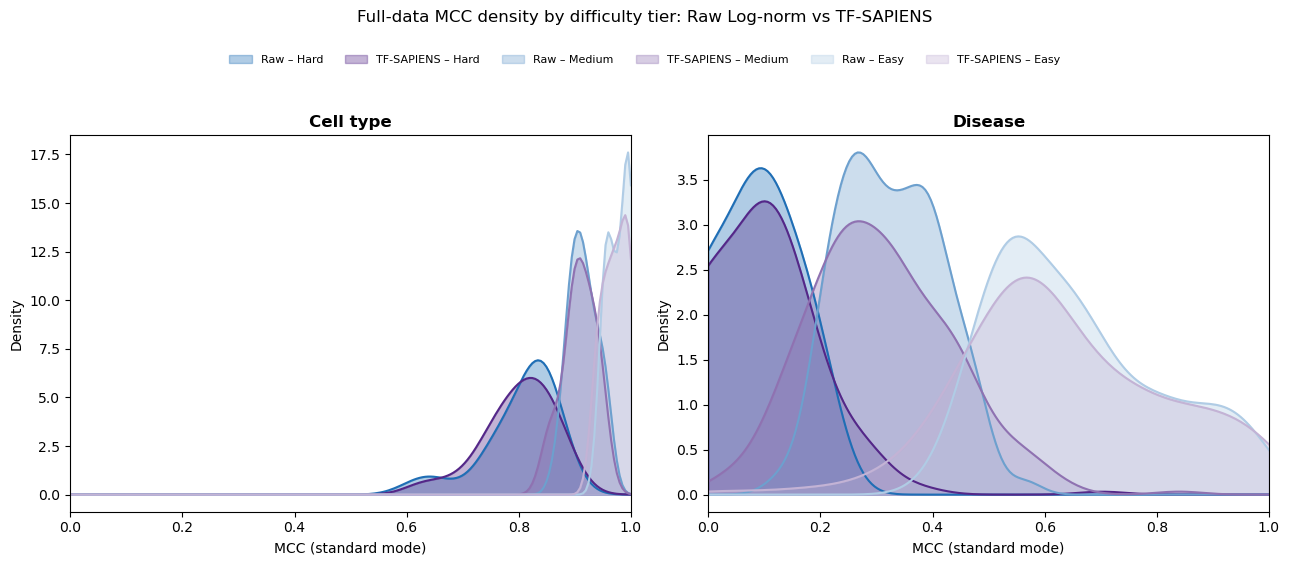

In [27]:
import numpy as np
from scipy.stats import gaussian_kde

_BLUE_DARK = "#1f6eb5"
_PURPLE_TF = "#542788"

def shade_hex(hex_color, lighten_amount):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    r = r + (1 - r) * lighten_amount
    g = g + (1 - g) * lighten_amount
    b = b + (1 - b) * lighten_amount
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

def tier_shades(base_color):
    return {"Hard": shade_hex(base_color, 0.0),
            "Medium": shade_hex(base_color, 0.35),
            "Easy": shade_hex(base_color, 0.65)}

RAW_SHADES = tier_shades(_BLUE_DARK)
TF_SHADES  = tier_shades(_PURPLE_TF)


def plot_mcc_kde_all_tiers(ax, df_full, difficulty_table, task_col,
                            benchmark_label, x_grid=None, fill_alpha=0.35):
    if x_grid is None:
        x_grid = np.linspace(0, 1, 200)

    raw_data = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, RAW)
    tf_data  = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, MODEL)

    for tier in TIERS:
        for data, shades, feat_label in [(raw_data, RAW_SHADES, "Raw"),
                                          (tf_data, TF_SHADES, "TF-SAPIENS")]:
            vals = data.loc[data["difficulty_tier"] == tier, "MCC"].dropna()
            if len(vals) > 1 and vals.std() > 0:
                kde = gaussian_kde(vals)
                y = kde(x_grid)
                color = shades[tier]
                ax.plot(x_grid, y, color=color, linewidth=1.5)
                ax.fill_between(x_grid, y, color=color, alpha=fill_alpha,
                                 label=f"{feat_label} – {tier}")

    ax.set_title(benchmark_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("MCC (standard mode)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_mcc_kde_all_tiers(axes[0], df_full=celltype_full,
                        difficulty_table=difficulty_ct, task_col="dataset_id",
                        benchmark_label="Cell type")
plot_mcc_kde_all_tiers(axes[1], df_full=disease_full,
                        difficulty_table=difficulty_disease, task_col="task_id",
                        benchmark_label="Disease")

# Single shared legend (6 entries: Raw/TF × Hard/Medium/Easy)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6,
           bbox_to_anchor=(0.5, 1.05), fontsize=8, frameon=False)

fig.suptitle("Full-data MCC density by difficulty tier: Raw Log-norm vs TF-SAPIENS", y=1.12)
plt.tight_layout()

#plt.savefig("MCC_kde_by_tier_2panels.png", dpi=300, bbox_inches="tight")
plt.show()

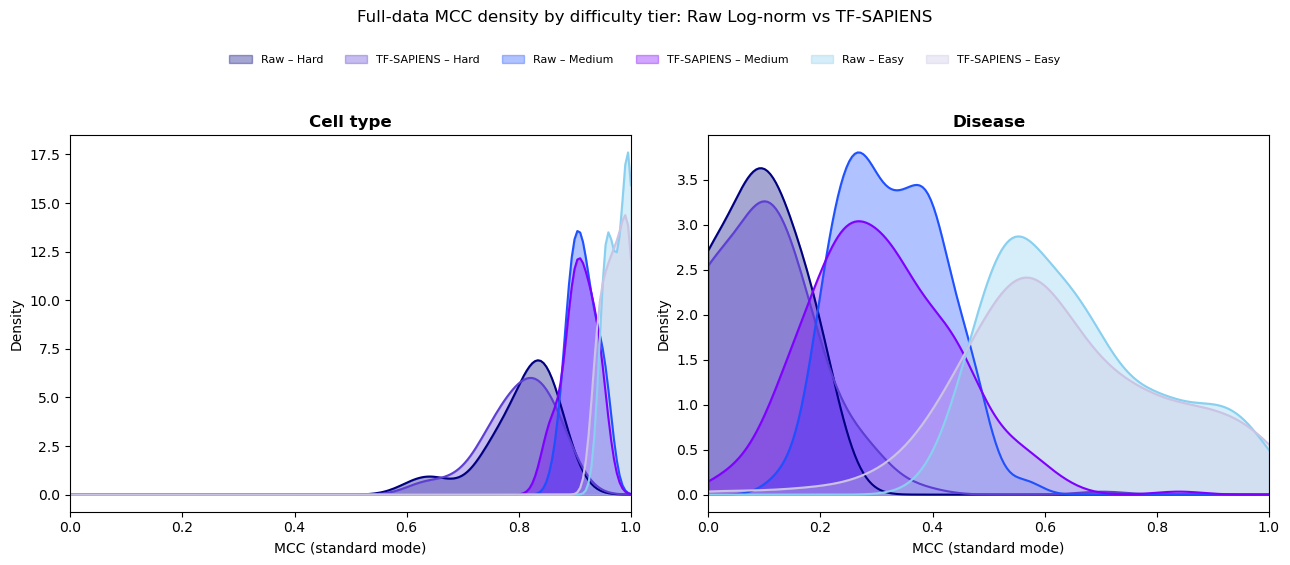

In [28]:
import numpy as np
from scipy.stats import gaussian_kde

_BLUE_DARK  = "#000080"
_BLUE_MID   = "#1F51FF"
_BLUE_LIGHT = "#89CFF0"

# Purple — TF
_PURPLE_DARK  = "#5D3FD3"
_PURPLE_MID   = "#7F00FF"  # original
_PURPLE_LIGHT = "#CBC3E3"

RAW_SHADES = {"Hard": _BLUE_DARK,   "Medium": _BLUE_MID,   "Easy": _BLUE_LIGHT}
TF_SHADES  = {"Hard": _PURPLE_DARK, "Medium": _PURPLE_MID, "Easy": _PURPLE_LIGHT}



def plot_mcc_kde_all_tiers(ax, df_full, difficulty_table, task_col,
                            benchmark_label, x_grid=None, fill_alpha=0.35):
    if x_grid is None:
        x_grid = np.linspace(0, 1, 200)

    raw_data = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, RAW)
    tf_data  = get_full_data_mcc_by_tier(df_full, difficulty_table, task_col, MODEL)

    for tier in TIERS:
        for data, shades, feat_label in [(raw_data, RAW_SHADES, "Raw"),
                                          (tf_data, TF_SHADES, "TF-SAPIENS")]:
            vals = data.loc[data["difficulty_tier"] == tier, "MCC"].dropna()
            if len(vals) > 1 and vals.std() > 0:
                kde = gaussian_kde(vals)
                y = kde(x_grid)
                color = shades[tier]
                ax.plot(x_grid, y, color=color, linewidth=1.5)
                ax.fill_between(x_grid, y, color=color, alpha=fill_alpha,
                                 label=f"{feat_label} – {tier}")

    ax.set_title(benchmark_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("MCC (standard mode)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_mcc_kde_all_tiers(axes[0], df_full=celltype_full,
                        difficulty_table=difficulty_ct, task_col="dataset_id",
                        benchmark_label="Cell type")
plot_mcc_kde_all_tiers(axes[1], df_full=disease_full,
                        difficulty_table=difficulty_disease, task_col="task_id",
                        benchmark_label="Disease")

# Single shared legend (6 entries: Raw/TF × Hard/Medium/Easy)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6,
           bbox_to_anchor=(0.5, 1.05), fontsize=8, frameon=False)

fig.suptitle("Full-data MCC density by difficulty tier: Raw Log-norm vs TF-SAPIENS", y=1.12)
plt.tight_layout()

#plt.savefig("MCC_kde_by_tier_2panels.png", dpi=300, bbox_inches="tight")
plt.show()

## 8/9 droping mcc taks

In [29]:
def find_nonmonotonic_tasks(df_low, task_col, feature, metric="MCC", min_drop=0.05):
    """
    Flags tasks whose trajectory decreases somewhere as n_per_class increases,
    anywhere along the range -- not restricted to a single n. Returns one row
    per task with the size of its single worst drop and where it happened.
    """
    agg = (
        df_low[df_low["feature_clean"] == feature]
        .groupby([task_col, "n_per_class"])[metric]
        .mean()
        .reset_index()
    )

    rows = []
    for tid, g in agg.groupby(task_col):
        g = g.sort_values("n_per_class")
        vals = g[metric].values
        ns = g["n_per_class"].values
        diffs = vals[1:] - vals[:-1]   # step-to-step change; negative = drop
        if len(diffs) == 0:
            continue
        worst_idx = diffs.argmin()
        worst_drop = -diffs[worst_idx]   # positive number = size of the drop
        if worst_drop >= min_drop:
            rows.append({
                task_col: tid,
                "worst_drop": worst_drop,
                "drop_from_n": ns[worst_idx],
                "drop_to_n": ns[worst_idx + 1],
                "n_nonmonotonic_steps": (diffs < 0).sum(),
                "total_steps": len(diffs),
            })

    return pd.DataFrame(rows).sort_values("worst_drop", ascending=False)


# Run across all four combinations he was looking at
nonmono_ct_raw = find_nonmonotonic_tasks(celltype_low, "dataset_id", RAW, metric="MCC")
nonmono_ct_tf  = find_nonmonotonic_tasks(celltype_low, "dataset_id", MODEL, metric="MCC")
nonmono_dis_raw = find_nonmonotonic_tasks(disease_low, "task_id", RAW, metric="MCC")
nonmono_dis_tf  = find_nonmonotonic_tasks(disease_low, "task_id", MODEL, metric="MCC")

print(f"Cell type Raw: {len(nonmono_ct_raw)} tasks with a drop ≥ 0.05 somewhere")
print(f"Cell type TF:  {len(nonmono_ct_tf)} tasks with a drop ≥ 0.05 somewhere")
print(f"Disease Raw:   {len(nonmono_dis_raw)} tasks with a drop ≥ 0.05 somewhere")
print(f"Disease TF:    {len(nonmono_dis_tf)} tasks with a drop ≥ 0.05 somewhere")

display(nonmono_ct_tf.head(10))

KeyError: 'worst_drop'

In [12]:
display(nonmono_dis_raw)

,task_id,worst_drop,drop_from_n,drop_to_n,n_nonmonotonic_steps,total_steps
54,6cf3634d-e911-44ad-bf52-c747a9af3c01::pericyte,0.421500,256.0,512.0,1,9
92,a199ca73-035d-44e2-9893-4c493151db21::memory B...,0.246593,16.0,32.0,4,9
70,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35::neutrophil,0.205826,16.0,32.0,7,9
43,574e9f9e-f8b4-41ef-bf19-89a9964fd9c7::CD4-posi...,0.199242,256.0,512.0,4,9
10,1c739a3e-c3f5-49d5-98e0-73975e751201::cardiac ...,0.144613,16.0,32.0,6,9
...,...,...,...,...,...,...
160,f1606894-59df-4794-a37f-baa7c6fb6de1::mesothel...,0.051637,16.0,32.0,4,9
102,b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-posi...,0.051189,256.0,512.0,7,9
157,edc8d3fe-153c-4e3d-8be0-2108d30f8d70::macrophage,0.050399,2.0,4.0,5,9
55,6f7fd0f1-a2ed-4ff1-80d3-33dde731cbc3::L5 extra...,0.050246,512.0,1024.0,2,9


In [30]:
def find_declining_trend_tasks(df_low, task_col, feature, metric="MCC", n_min=2, n_max=1024):
    """
    Flags tasks where the metric at n_max is LOWER than at n_min -- i.e. the
    whole trajectory trends downward net, not just dipping somewhere in the
    middle. Also fits a simple slope across all n so partial/noisy endpoints
    don't drive false positives.
    """
    agg = (
        df_low[df_low["feature_clean"] == feature]
        .groupby([task_col, "n_per_class"])[metric]
        .mean()
        .reset_index()
    )

    rows = []
    for tid, g in agg.groupby(task_col):
        g = g.sort_values("n_per_class")
        if n_min not in g["n_per_class"].values or n_max not in g["n_per_class"].values:
            continue

        val_min = g.loc[g["n_per_class"] == n_min, metric].iloc[0]
        val_max = g.loc[g["n_per_class"] == n_max, metric].iloc[0]
        net_change = val_max - val_min   # negative = worse at n_max than n_min

        # Also fit a slope across log2(n) vs metric, over ALL n points --
        # a robustness check so one noisy endpoint alone doesn't flag a task
        # whose overall trend is actually still upward.
        log_n = np.log2(g["n_per_class"].values)
        slope = np.polyfit(log_n, g[metric].values, 1)[0]

        rows.append({
            task_col: tid,
            f"{metric}_at_{n_min}": val_min,
            f"{metric}_at_{n_max}": val_max,
            "net_change": net_change,
            "overall_slope": slope,
        })

    df_out = pd.DataFrame(rows)
    # Tasks where BOTH the endpoint comparison AND the overall trend agree it's declining
    declining = df_out[(df_out["net_change"] < 0) & (df_out["overall_slope"] < 0)]
    return df_out.sort_values("net_change"), declining.sort_values("net_change")


# Run for each benchmark x feature combination
all_ct_raw, declining_ct_raw = find_declining_trend_tasks(celltype_low, "dataset_id", RAW)
all_ct_tf,  declining_ct_tf  = find_declining_trend_tasks(celltype_low, "dataset_id", MODEL)
all_dis_raw, declining_dis_raw = find_declining_trend_tasks(disease_low, "task_id", RAW)
all_dis_tf,  declining_dis_tf  = find_declining_trend_tasks(disease_low, "task_id", MODEL)

print(f"Cell type Raw: {len(declining_ct_raw)} / {len(all_ct_raw)} tasks decline net (n=2 -> n=1024)")
print(f"Cell type TF:  {len(declining_ct_tf)} / {len(all_ct_tf)} tasks decline net")
print(f"Disease Raw:   {len(declining_dis_raw)} / {len(all_dis_raw)} tasks decline net")
print(f"Disease TF:    {len(declining_dis_tf)} / {len(all_dis_tf)} tasks decline net")

display(declining_ct_tf.head(10))

Cell type Raw: 0 / 62 tasks decline net (n=2 -> n=1024)
Cell type TF:  0 / 62 tasks decline net
Disease Raw:   79 / 862 tasks decline net
Disease TF:    91 / 862 tasks decline net


,dataset_id,MCC_at_2,MCC_at_1024,net_change,overall_slope


In [31]:
declining_dis_raw

,task_id,MCC_at_2,MCC_at_1024,net_change,overall_slope
403,8fbed309-d3d4-441b-b3ff-e2dcbcec2d35::neutrophil,-0.041612,-0.466470,-0.424858,-0.054759
234,4dd1cd23-fc4d-4fd1-9709-602540f3ca6f::oligoden...,-0.020961,-0.303978,-0.283016,-0.035410
779,e6361237-ac4e-4c5d-ad8f-f16aca0c0a8f::oligoden...,0.015036,-0.256611,-0.271647,-0.037836
31,0f4865d5-8000-4f68-8ac7-f5efea9e5e70::myofibro...,0.011776,-0.220690,-0.232466,-0.024046
380,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::adipocyte,-0.003750,-0.221217,-0.217467,-0.026711
...,...,...,...,...,...
524,a37f857c-779f-464e-9310-3db43a1811e7::plasma cell,-0.030414,-0.047092,-0.016678,-0.000222
205,3c75a463-6a87-4132-83a8-c3002624394d::regulato...,-0.018661,-0.032730,-0.014069,-0.002028
193,3c75a463-6a87-4132-83a8-c3002624394d::effector...,-0.016312,-0.025575,-0.009263,-0.003475
776,e6361237-ac4e-4c5d-ad8f-f16aca0c0a8f::microgli...,0.012291,0.003775,-0.008516,-0.000253


In [32]:
disease_low.query('task_id.isin(@declining_dis_raw.task_id)').drop_duplicates('task_id').dataset_id.value_counts()

dataset_id
b61a921b-7fa3-4b42-b455-aaaf32447920    13
3c75a463-6a87-4132-83a8-c3002624394d    11
8fbed309-d3d4-441b-b3ff-e2dcbcec2d35     7
d18736c3-6292-4379-919a-d6d973204c87     6
8f4f8502-9170-4ac2-9707-3b6985ebfe5f     5
99950e99-2758-41d2-b2c9-643edcdf6d82     3
df1edb87-e512-43ae-b5f4-cb179cfc2bb4     3
a199ca73-035d-44e2-9893-4c493151db21     3
e6361237-ac4e-4c5d-ad8f-f16aca0c0a8f     3
1c739a3e-c3f5-49d5-98e0-73975e751201     2
b3a5a10f-b1cb-4e8e-abce-bf345448625b     2
f1606894-59df-4794-a37f-baa7c6fb6de1     2
6c600df6-ddca-4628-a8bb-1d6de1e3f9b4     2
a37f857c-779f-464e-9310-3db43a1811e7     2
2856d06c-0ff9-4e01-bfc9-202b74d0b60f     1
7b20c613-9add-43d1-87e9-defd3d9b9f8c     1
251b1a7e-d050-4486-8d50-4c2619eb0f46     1
07760522-707a-4a1c-8891-dbd1226d6b27     1
19e46756-9100-4e01-8b0e-23b557558a4c     1
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1     1
576f193c-75d0-4a11-bd25-8676587e6dc2     1
0f4865d5-8000-4f68-8ac7-f5efea9e5e70     1
c893ddc3-f25b-45e2-8c9e-155918b4261c     1


In [33]:
disease_low.columns

Index(['fold', 'n_train', 'n_test', 'n_per_class', 'bootstrap', 'dataset_id',
       'cell_type', 'n_genes', 'balanced_acc', 'MCC', 'F1_macro',
       'recall_macro', 'n_unknown_labels', 'n_valid_test_samples', 'log_loss',
       'AUROC', 'AUPRC', 'balanced_acc_donor', 'MCC_donor', 'F1_macro_donor',
       'recall_macro_donor', 'mean_donor_acc', 'worst_donor_acc',
       'std_donor_acc', 'n_valid_donors', 'feature', 'metric_error',
       'proba_unavailable', 'AUROC_ovr', 'error', 'donor_metric_error',
       'skip_reason', 'feature_clean', 'task_id', 'n_tasks', 'n_folds',
       'difficulty_score', 'difficulty_tier'],
      dtype='object')

In [52]:
disease_low.query('task_id=="b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-positive, alpha-beta T cell"').bootstrap.value_counts()

bootstrap
0.0    140
1.0    140
2.0    140
3.0    140
4.0    140
Name: count, dtype: int64

In [53]:
pd.crosstab(disease_low.query('task_id=="b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-positive, alpha-beta T cell"').bootstrap,disease_low.query('task_id=="b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-positive, alpha-beta T cell"').fold)

fold,fold_4,fold_5
bootstrap,,
0.0,70,70
1.0,70,70
2.0,70,70
3.0,70,70
4.0,70,70


In [82]:
declining_task_ids = declining_dis_raw["task_id"].tolist()  # or whichever set you're working with

# ============================================================
# Step 1: pull raw per-bootstrap, per-fold values at n=2 and n=1024
# ============================================================
diag = disease_low[
    (disease_low["feature_clean"] == MODEL) &
    (disease_low["task_id"].isin(declining_task_ids)) &
    (disease_low["n_per_class"].isin([2, 1024]))
].copy()

for tid in declining_task_ids[:10]:  # start with the worst offenders
    sub = diag[diag["task_id"] == tid].sort_values(["n_per_class", "bootstrap", "fold"])
    print(f"\n=== {tid} ===")

    summary = sub.groupby("n_per_class")["MCC"].agg(["mean", "std", "min", "max", "count"])
    display(summary)


=== 8fbed309-d3d4-441b-b3ff-e2dcbcec2d35::neutrophil ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,0.006373,0.344164,-0.471405,0.522233,10
1024.0,-0.118191,0.124584,-0.236382,0.000000,10



=== 4dd1cd23-fc4d-4fd1-9709-602540f3ca6f::oligodendrocyte precursor cell ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,-0.231593,0.293430,-0.692093,0.231664,10
1024.0,-0.154124,0.353292,-0.490650,0.384716,10



=== e6361237-ac4e-4c5d-ad8f-f16aca0c0a8f::oligodendrocyte precursor cell ===


...

,mean,std,min,max,count
n_per_class,,,,,
2.0,0.075866,0.143205,-0.119804,0.433433,15
1024.0,0.016424,0.027958,-0.021108,0.041341,15



=== b61a921b-7fa3-4b42-b455-aaaf32447920::natural killer cell ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,0.022008,0.134838,-0.300863,0.324416,20
1024.0,0.156644,0.404417,-0.500000,1.000000,20



=== b61a921b-7fa3-4b42-b455-aaaf32447920::endothelial cell of lymphatic vessel ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,-0.057974,0.256566,-0.508515,0.401067,20
1024.0,-0.131176,0.164741,-0.377091,0.073088,20


In [83]:
# ============================================================
# Step 2: check if these tasks have very few total cells --
# could cause n=1024 to draw from an exhausted, near-identical
# pool repeatedly across bootstraps and folds, which is a
# different failure mode than "just needs more resamples"
# ============================================================
diag[["task_id", "n_per_class", "n_train", "n_test"]].groupby(
    ["task_id", "n_per_class"]
).agg(["mean", "min", "max"])

n_train  \
                                                                       mean   
task_id                                            n_per_class                
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0             4.000000   
                                                   1024.0       2048.000000   
0f4865d5-8000-4f68-8ac7-f5efea9e5e70::myofibrob... 2.0             4.000000   
                                                   1024.0       1341.333333   
19e46756-9100-4e01-8b0e-23b557558a4c::CD14-posi... 2.0             4.000000   
...                                                                     ...   
f1606894-59df-4794-a37f-baa7c6fb6de1::mesotheli... 1024.0       2048.000000   
f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglia... 2.0             4.000000   
                                                   1024.0       2048.000000   
fe4b89d5-461e-440c-a5a8-621b37b122c0::type EC e... 2.0             4.000000   
                                                   1024.0        548.800000   

                                                                        \
                                                                   min   
task_id                                            n_per_class           
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0             4.0   
                                                   1024.0       2048.0   
0f4865d5-8000-4f68-8ac7-f5efea9e5e70::myofibrob... 2.0             4.0   
                                                   1024.0       1062.0   
19e46756-9100-4e01-8b0e-23b557558a4c::CD14-posi... 2.0             4.0   
...                                                                ...   
f1606894-59df-4794-a37f-baa7c6fb6de1::mesotheli... 1024.0       2048.0   
f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglia... 2.0             4.0   
                                                   1024.0       2048.0   
fe4b89d5-461e-440c-a5a8-621b37b122c0::type EC e... 2.0             4.0   
                                                   1024.0        460.0   

                                                                        \
                                                                   max   
task_id                                            n_per_class           
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0             4.0   
                                                   1024.0       2048.0   
0f4865d5-8000-4f68-8ac7-f5efea9e5e70::myofibrob... 2.0             4.0   
                                                   1024.0       1497.0   
19e46756-9100-4e01-8b0e-23b557558a4c::CD14-posi... 2.0             4.0   
...                                                                ...   
f1606894-59df-4794-a37f-baa7c6fb6de1::mesotheli... 1024.0       2048.0   
f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglia... 2.0             4.0   
                                                   1024.0       2048.0   
fe4b89d5-461e-440c-a5a8-621b37b122c0::type EC e... 2.0             4.0   
                                                   1024.0        657.0   

                                                                     n_test  \
                                                                       mean   
task_id                                            n_per_class                
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0          5096.500000   
                                                   1024.0       5096.500000   
0f4865d5-8000-4f68-8ac7-f5efea9e5e70::myofibrob... 2.0           342.000000   
                                                   1024.0        342.000000   
19e46756-9100-4e01-8b0e-23b557558a4c::CD14-posi... 2.0          3947.000000   
...                                                                     ...   
f1606894-59df-4794-a37f-baa7c6fb6de1::mesotheli... 1024.0       5594.800000   
f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglia... 2.0          3826.666667   
                  

In [84]:
# 1. Generate the aggregated DataFrame
grouped_df = diag[["task_id", "n_per_class", "n_train", "n_test"]].groupby(
    ["task_id", "n_per_class"]
).agg(["mean", "min", "max"])

# 2. Filter the index where the 'task_id' level starts with your string
prefix = 'b61a921b-7fa3-4b42-b455-aaaf32447920'
result = grouped_df.loc[grouped_df.index.get_level_values('task_id').str.startswith(prefix, na=False)]

display(result)


n_train  \
                                                                       mean   
task_id                                            n_per_class                
b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-posit... 2.0             4.000000   
                                                   1024.0       1562.000000   
b61a921b-7fa3-4b42-b455-aaaf32447920::bronchiol... 2.0             4.000000   
                                                   1024.0        456.333333   
b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated ... 2.0             4.000000   
                                                   1024.0       2048.000000   
b61a921b-7fa3-4b42-b455-aaaf32447920::conventio... 2.0             4.000000   
                                                   1024.0       1204.666667   
b61a921b-7fa3-4b42-b455-aaaf32447920::endotheli... 2.0             4.000000   
                                                   1024.0        705.750000   
b61a921b-7fa3-4b42-b455-aaaf32447920::fibroblast   2.0             4.000000   
                                                   1024.0       1225.666667   
b61a921b-7fa3-4b42-b455-aaaf32447920::lung micr... 2.0             4.000000   
                                                   1024.0       1177.000000   
b61a921b-7fa3-4b42-b455-aaaf32447920::mast cell    2.0             4.000000   
                                                   1024.0       1750.000000   
b61a921b-7fa3-4b42-b455-aaaf32447920::mature NK... 2.0             4.000000   
                                                   1024.0       1715.500000   
b61a921b-7fa3-4b42-b455-aaaf32447920::monocyte     2.0             4.000000   
                                                   1024.0       1859.250000   
b61a921b-7fa3-4b42-b455-aaaf32447920::natural k... 2.0             4.000000   
                                                   1024.0       1180.000000   
b61a921b-7fa3-4b42-b455-aaaf32447920::unknown      2.0             4.000000   
                                                   1024.0        628.250000   
b61a921b-7fa3-4b42-b455-aaaf32447920::vascular ... 2.0             4.000000   
                                                   1024.0        376.500000   

                                                                        \
                                                                   min   
task_id                                            n_per_class           
b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-posit... 2.0             4.0   
                                                   1024.0       1458.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::bronchiol... 2.0             4.0   
                                                   1024.0        231.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated ... 2.0             4.0   
                                                   1024.0       2048.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::conventio... 2.0             4.0   
                                                   1024.0       1113.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::endotheli... 2.0             4.0   
                                                   1024.0        636.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::fibroblast   2.0             4.0   
                                                   1024.0       1219.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::lung micr... 2.0             4.0   
                                                   1024.0       1086.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::mast cell    2.0             4.0   
                                                   1024.0       1154.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::mature NK... 2.0             4.0   
                                                   1024.0       1420.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::monocyte     2.0             4.0   
                                                   1024.0       1293.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::natural k... 2.0             4.0   


In [85]:
# ============================================================
# Step 3: compare against standard/full-data MCC for the same tasks --
# does performance keep climbing past n=1024 toward standard mode,
# or does it plateau/decline there too?
# ============================================================
standard_vals = (
    disease_full[
        (disease_full["feature_clean"] == MODEL) &
        (disease_full["task_id"].isin(declining_task_ids))
    ]
    .groupby("task_id")["MCC"]
    .mean()
    .rename("MCC_standard")
)

comparison = declining_dis_raw.set_index("task_id")[["MCC_at_2", "MCC_at_1024"]].join(standard_vals)
comparison["gap_1024_to_standard"] = comparison["MCC_standard"] - comparison["MCC_at_1024"]
display(comparison.sort_values("gap_1024_to_standard"))

,MCC_at_2,MCC_at_1024,MCC_standard,gap_1024_to_standard
task_id,,,,
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,-0.123082,-0.231564,-0.528758,-0.297195
"3c75a463-6a87-4132-83a8-c3002624394d::naive thymus-derived CD8-positive, alpha-beta T cell",0.012189,-0.075660,-0.266304,-0.190644
b61a921b-7fa3-4b42-b455-aaaf32447920::bronchiolar smooth muscle cell,0.040027,0.005186,-0.119677,-0.124863
8fbed309-d3d4-441b-b3ff-e2dcbcec2d35::smooth muscle cell,0.006135,-0.107660,-0.210741,-0.103080
b61a921b-7fa3-4b42-b455-aaaf32447920::mast cell,-0.010131,-0.066507,-0.151335,-0.084828
...,...,...,...,...
b61a921b-7fa3-4b42-b455-aaaf32447920::natural killer cell,0.012877,-0.158581,0.028098,0.186679
d18736c3-6292-4379-919a-d6d973204c87::naive B cell,0.039846,-0.030150,0.157344,0.187494
3c75a463-6a87-4132-83a8-c3002624394d::classical monocyte,-0.004101,-0.087695,0.125122,0.212817


In [86]:
from scipy.stats import wilcoxon

def test_decline_significance(diag, task_col, tid, n_low=2, n_high=1024):
    """
    Paired Wilcoxon signed-rank test: is MCC at n_high genuinely lower than
    at n_low, for the SAME (fold, bootstrap) pairs? Since the CV fold split
    is fixed across n, these pairs share the same test set -- a real paired
    comparison, not just two independent samples.
    """
    sub = diag[diag[task_col] == tid]
    low = sub[sub["n_per_class"] == n_low].sort_values(["bootstrap", "fold"])
    high = sub[sub["n_per_class"] == n_high].sort_values(["bootstrap", "fold"])

    # align on (bootstrap, fold) so we're comparing the same test set each time
    merged = low.merge(high, on=["bootstrap", "fold"], suffixes=("_low", "_high"))
    if len(merged) < 5:
        return None  # too few paired points to test meaningfully

    diff = merged["MCC_high"] - merged["MCC_low"]
    if (diff == 0).all():
        return {"task": tid, "n_pairs": len(diff), "p_value": 1.0, "median_diff": 0.0}

    stat, p = wilcoxon(diff, alternative="less")  # testing high < low
    return {
        "task": tid,
        "n_pairs": len(diff),
        "median_diff": diff.median(),
        "p_value": p,
    }


results = []
for tid in comparison.index:  # the 30 non-ceiling declining tasks
    res = test_decline_significance(diag, "task_id", tid)
    if res:
        results.append(res)

decline_test_df = pd.DataFrame(results).sort_values("p_value")
decline_test_df["significant"] = decline_test_df["p_value"] < 0.05
print(f"{decline_test_df['significant'].sum()} / {len(decline_test_df)} declines are statistically significant (uncorrected)")
display(decline_test_df)

13 / 79 declines are statistically significant (uncorrected)


,task,n_pairs,median_diff,p_value,significant
24,07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,10,-0.329741,0.000977,True
18,99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,10,-0.268090,0.000977,True
51,d18736c3-6292-4379-919a-d6d973204c87::gamma-de...,20,-0.101741,0.001827,True
11,b61a921b-7fa3-4b42-b455-aaaf32447920::CD4-posi...,10,-0.206610,0.002930,True
26,3c75a463-6a87-4132-83a8-c3002624394d::macrophage,25,-0.161143,0.005727,True
...,...,...,...,...,...
6,b61a921b-7fa3-4b42-b455-aaaf32447920::vascular...,20,0.250508,0.995988,False
72,d18736c3-6292-4379-919a-d6d973204c87::memory B...,25,0.114553,0.997912,False
70,b61a921b-7fa3-4b42-b455-aaaf32447920::lung mic...,20,0.073449,0.998424,False
62,3c75a463-6a87-4132-83a8-c3002624394d::plasma cell,20,0.228766,0.999007,False


In [87]:
from statsmodels.stats.multitest import multipletests
_, decline_test_df["p_holm"], _, _ = multipletests(decline_test_df["p_value"], method="holm")
decline_test_df["significant_holm"] = decline_test_df["p_holm"] < 0.05
print(f"{decline_test_df['significant_holm'].sum()} / {len(decline_test_df)} declines survive Holm correction")

0 / 79 declines survive Holm correction


In [102]:
import pandas as pd

disease_manifest = pd.read_parquet("disease_filter_bug_audit.parquet")
celltype_manifest = pd.read_csv("celltype_manifest.csv")

# Build task_id -> n_classes lookups
disease_manifest["task_id"] = (
    disease_manifest["dataset_id"].astype(str) + "::" + disease_manifest["cell_type"].astype(str)
)
n_classes_disease = disease_manifest.drop_duplicates("task_id").set_index("task_id")["n_diseases_actual"]
n_classes_celltype = celltype_manifest.drop_duplicates("dataset_id").set_index("dataset_id")["n_cell_types"]


def find_ceiling_limited_tasks(df_low, task_col, n_classes_lookup, tol=100):
    """
    Flags (task, n_per_class) rows where n_train fell short of the expected
    n_per_class * n_classes target -- meaning downsampling ran out of cells
    for at least one class. Returns the set of task_ids that hit this ceiling
    at ANY n_per_class value (these should be dropped entirely, since a
    trajectory with a silently-truncated point isn't comparable across n).
    """
    df = df_low.copy()
    df["n_classes"] = df[task_col].map(n_classes_lookup)
    df = df.dropna(subset=["n_classes"])
    df["expected_n_train"] = df["n_per_class"] * df["n_classes"]

    # worst case per (task, n): the minimum n_train seen across folds/bootstraps
    worst = (
        df.groupby([task_col, "n_per_class"])
        .agg(n_train_min=("n_train", "min"), expected=("expected_n_train", "first"))
        .reset_index()
    )
    worst["met"] = worst["n_train_min"] >= (worst["expected"] - tol)

    ceiling_limited_tasks = worst.loc[~worst["met"], task_col].unique()
    return set(ceiling_limited_tasks), worst


ceiling_ct, worst_ct = find_ceiling_limited_tasks(celltype_low, "dataset_id", n_classes_celltype)
ceiling_dis, worst_dis = find_ceiling_limited_tasks(disease_low, "task_id", n_classes_disease)

print(f"Cell type: {len(ceiling_ct)} / {celltype_low['dataset_id'].nunique()} tasks hit the ceiling at some n")
print(f"Disease:   {len(ceiling_dis)} / {disease_low['task_id'].nunique()} tasks hit the ceiling at some n")

# ============================================================
# Subset: keep only "clean" tasks -- never hit the ceiling at ANY n
# Apply the same clean task list to BOTH low-data AND standard dataframes,
# so every analysis downstream uses a consistent set of tasks.
# ============================================================

clean_celltype_ids = set(celltype_low["dataset_id"].unique()) - ceiling_ct
clean_disease_ids  = set(disease_low["task_id"].unique()) - ceiling_dis

celltype_low_clean  = celltype_low[celltype_low["dataset_id"].isin(clean_celltype_ids)].copy()
celltype_full_clean = celltype_full[celltype_full["dataset_id"].isin(clean_celltype_ids)].copy()
disease_low_clean   = disease_low[disease_low["task_id"].isin(clean_disease_ids)].copy()
disease_full_clean  = disease_full[disease_full["task_id"].isin(clean_disease_ids)].copy()

print(f"\nCell type: kept {len(clean_celltype_ids)} / {celltype_low['dataset_id'].nunique()} tasks")
print(f"Disease:   kept {len(clean_disease_ids)} / {disease_low['task_id'].nunique()} tasks")

Cell type: 48 / 62 tasks hit the ceiling at some n
Disease:   569 / 862 tasks hit the ceiling at some n

Cell type: kept 14 / 62 tasks
Disease:   kept 293 / 862 tasks


In [123]:
worst_dis

,task_id,n_per_class,n_train_min,expected,met
0,01ad3cd7-3929-4654-84c0-6db05bd5fd59::B cell,2.0,6.0,6.0,True
1,01ad3cd7-3929-4654-84c0-6db05bd5fd59::B cell,4.0,12.0,12.0,True
2,01ad3cd7-3929-4654-84c0-6db05bd5fd59::B cell,8.0,24.0,24.0,True
3,01ad3cd7-3929-4654-84c0-6db05bd5fd59::B cell,16.0,48.0,48.0,True
4,01ad3cd7-3929-4654-84c0-6db05bd5fd59::B cell,32.0,96.0,96.0,True
...,...,...,...,...,...
8615,fe4b89d5-461e-440c-a5a8-621b37b122c0::type L e...,64.0,128.0,128.0,True
8616,fe4b89d5-461e-440c-a5a8-621b37b122c0::type L e...,128.0,234.0,256.0,True
8617,fe4b89d5-461e-440c-a5a8-621b37b122c0::type L e...,256.0,362.0,512.0,False
8618,fe4b89d5-461e-440c-a5a8-621b37b122c0::type L e...,512.0,557.0,1024.0,False


In [125]:
disease_low["n_train"]

0             4.0
1             4.0
2             4.0
3             4.0
4             4.0
            ...  
1246310    1997.0
1246311    2048.0
1246312    1844.0
1246313    2048.0
1246314    1997.0
Name: n_train, Length: 1246315, dtype: float64

In [103]:
def ceiling_hit_rate_by_n(worst_df, task_col):
    """Shows what fraction of tasks fail the ceiling check at EACH n_per_class
    separately, so you can see exactly where the big drop-offs happen."""
    return (
        worst_df.groupby("n_per_class")
        .agg(
            n_tasks=(task_col, "nunique"),
            n_failed=("met", lambda x: (~x).sum()),
        )
        .assign(pct_failed=lambda d: (d["n_failed"] / d["n_tasks"] * 100).round(1))
    )

print("Cell type — ceiling failure rate per n_per_class:")
display(ceiling_hit_rate_by_n(worst_ct, "dataset_id"))

print("\nDisease — ceiling failure rate per n_per_class:")
display(ceiling_hit_rate_by_n(worst_dis, "task_id"))

Cell type — ceiling failure rate per n_per_class:


,n_tasks,n_failed,pct_failed
n_per_class,,,
2.0,62,0,0.0
4.0,62,0,0.0
8.0,62,0,0.0
16.0,62,0,0.0
32.0,62,0,0.0
64.0,62,0,0.0
128.0,62,1,1.6
256.0,62,2,3.2
512.0,62,34,54.8



Disease — ceiling failure rate per n_per_class:


,n_tasks,n_failed,pct_failed
n_per_class,,,
2.0,862,0,0.0
4.0,862,0,0.0
8.0,862,0,0.0
16.0,862,0,0.0
32.0,862,0,0.0
64.0,862,9,1.0
128.0,862,82,9.5
256.0,862,284,32.9
512.0,862,442,51.3


In [104]:
declining_disease_ids = set(declining_dis_tf["task_id"])  # from earlier
ceiling_disease_ids = ceiling_dis  # the full set that hit the ceiling at some n

overlap = declining_disease_ids & ceiling_disease_ids
print(f"{len(overlap)} / {len(declining_disease_ids)} declining tasks are ceiling-limited at some n")

62 / 92 declining tasks are ceiling-limited at some n


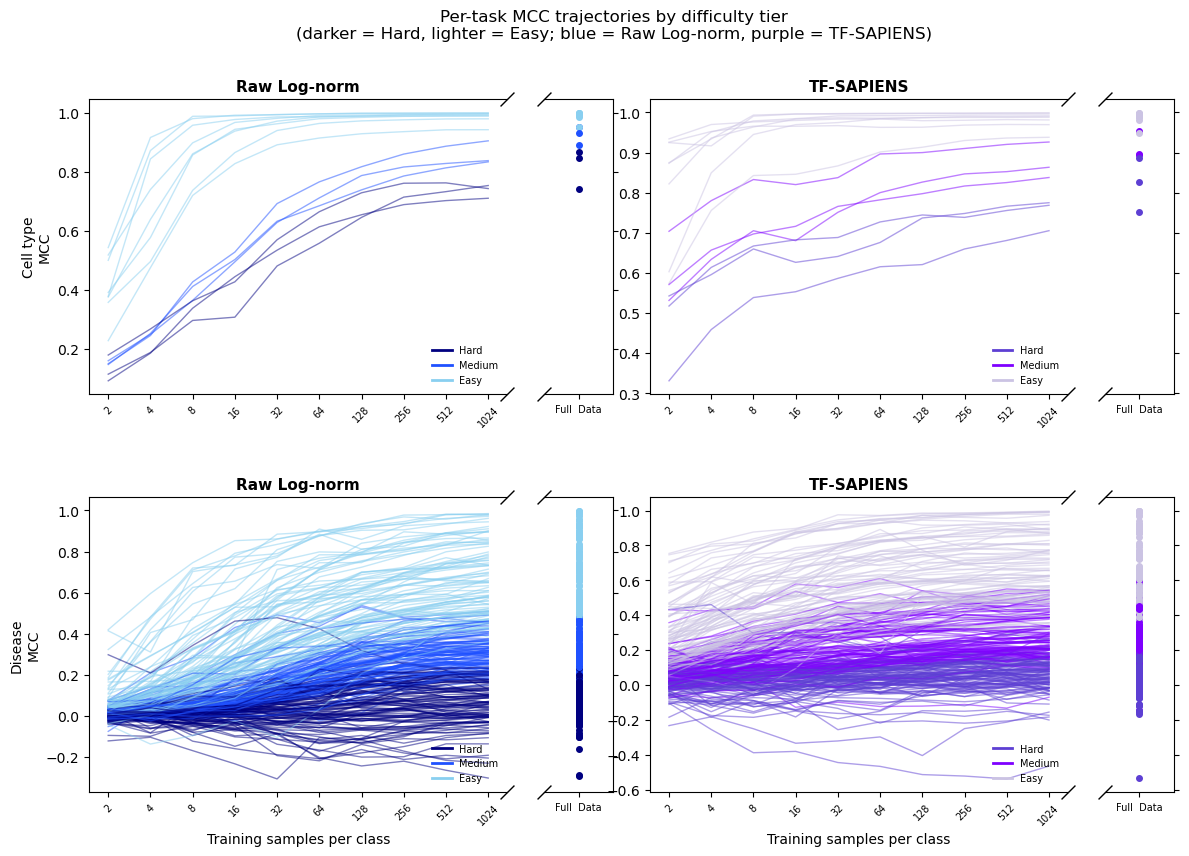

In [105]:

# ============================================================
# Assemble 2x2 figure: rows = benchmark, cols = feature
# (0,0)=Raw/celltype  (0,1)=TF/celltype
# (1,0)=Raw/disease   (1,1)=TF/disease
# ============================================================

    
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)

panels = [
    # (row, df_low, df_full, difficulty_table, task_col, benchmark_label, col, feature, shades, feature_label)
    (0, celltype_low_clean, celltype_full_clean, difficulty_ct,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low_clean, celltype_full_clean, difficulty_ct,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low_clean,  disease_full_clean,  difficulty_disease, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low_clean,  disease_full_clean,  difficulty_disease, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nMCC" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task MCC trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)


plt.show()

In [106]:



# Run for each benchmark x feature combination
all_ct_raw_clean, declining_ct_raw_clean = find_declining_trend_tasks(celltype_low_clean, "dataset_id", RAW)
all_ct_tf_clean,  declining_ct_tf_clean  = find_declining_trend_tasks(celltype_low_clean, "dataset_id", MODEL)
all_dis_raw_clean, declining_dis_raw_clean = find_declining_trend_tasks(disease_low_clean, "task_id", RAW)
all_dis_tf_clean,  declining_dis_tf_clean  = find_declining_trend_tasks(disease_low_clean, "task_id", MODEL)

print(f"Cell type Raw: {len(declining_ct_raw_clean)} / {len(all_ct_raw_clean)} tasks decline net (n=2 -> n=1024)")
print(f"Cell type TF:  {len(declining_ct_tf_clean)} / {len(all_ct_tf_clean)} tasks decline net")
print(f"Disease Raw:   {len(declining_dis_raw_clean)} / {len(all_dis_raw_clean)} tasks decline net")
print(f"Disease TF:    {len(declining_dis_tf_clean)} / {len(all_dis_tf_clean)} tasks decline net")

display(declining_ct_tf_clean.head(10))

Cell type Raw: 0 / 14 tasks decline net (n=2 -> n=1024)
Cell type TF:  0 / 14 tasks decline net
Disease Raw:   24 / 293 tasks decline net
Disease TF:    30 / 293 tasks decline net


,dataset_id,MCC_at_2,MCC_at_1024,net_change,overall_slope


In [107]:
declining_task_ids_clean = declining_dis_raw_clean["task_id"].tolist()  # or whichever set you're working with

# ============================================================
# Step 1: pull raw per-bootstrap, per-fold values at n=2 and n=1024
# ============================================================
diag_clean = disease_low_clean[
    (disease_low_clean["feature_clean"] == MODEL) &
    (disease_low_clean["task_id"].isin(declining_task_ids)) &
    (disease_low_clean["n_per_class"].isin([2, 1024]))
].copy()

for tid in declining_task_ids_clean[:10]:  # start with the worst offenders
    sub = diag_clean[diag_clean["task_id"] == tid].sort_values(["n_per_class", "bootstrap", "fold"])
    print(f"\n=== {tid} ===")

    summary = sub.groupby("n_per_class")["MCC"].agg(["mean", "std", "min", "max", "count"])
    display(summary)


=== 4dd1cd23-fc4d-4fd1-9709-602540f3ca6f::oligodendrocyte precursor cell ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,-0.231593,0.293430,-0.692093,0.231664,10
1024.0,-0.154124,0.353292,-0.490650,0.384716,10



=== f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglial cell ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,-0.022878,0.151986,-0.374349,0.206794,15
1024.0,-0.182424,0.161455,-0.477310,0.049629,15



=== 1c739a3e-c3f5-49d5-98e0-73975e751201::cardiac muscle myoblast ===


...

,mean,std,min,max,count
n_per_class,,,,,
2.0,-0.073757,0.290950,-0.423117,0.537300,15
1024.0,0.021638,0.190269,-0.461439,0.323028,15



=== 8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac blood vessel endothelial cell ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,0.075972,0.170948,-0.224534,0.450510,25
1024.0,-0.035512,0.146488,-0.396229,0.184678,25



=== 3c75a463-6a87-4132-83a8-c3002624394d::intermediate monocyte ===


,mean,std,min,max,count
n_per_class,,,,,
2.0,0.004103,0.223516,-0.490334,0.288830,20
1024.0,0.077231,0.125629,-0.150191,0.281069,20


In [108]:
# ============================================================
# Step 2: check if these tasks have very few total cells --
# could cause n=1024 to draw from an exhausted, near-identical
# pool repeatedly across bootstraps and folds, which is a
# different failure mode than "just needs more resamples"
# ============================================================
diag_clean[["task_id", "n_per_class", "n_train", "n_test"]].groupby(
    ["task_id", "n_per_class"]
).agg(["mean", "min", "max"])

n_train  \
                                                                  mean   
task_id                                            n_per_class           
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0             4.0   
                                                   1024.0       2048.0   
19e46756-9100-4e01-8b0e-23b557558a4c::CD14-posi... 2.0             4.0   
                                                   1024.0       2048.0   
1c739a3e-c3f5-49d5-98e0-73975e751201::cardiac m... 2.0             4.0   
                                                   1024.0       2048.0   
251b1a7e-d050-4486-8d50-4c2619eb0f46::neuron       2.0             4.0   
                                                   1024.0       2048.0   
3c75a463-6a87-4132-83a8-c3002624394d::classical... 2.0             4.0   
                                                   1024.0       2048.0   
3c75a463-6a87-4132-83a8-c3002624394d::intermedi... 2.0             4.0   
                                                   1024.0       2048.0   
3c75a463-6a87-4132-83a8-c3002624394d::regulator... 2.0             4.0   
                                                   1024.0       2048.0   
4dd1cd23-fc4d-4fd1-9709-602540f3ca6f::oligodend... 2.0             4.0   
                                                   1024.0       2048.0   
6c600df6-ddca-4628-a8bb-1d6de1e3f9b4::glutamate... 2.0             4.0   
                                                   1024.0       2048.0   
7b20c613-9add-43d1-87e9-defd3d9b9f8c::regulator... 2.0             4.0   
                                                   1024.0       2042.0   
8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac b... 2.0             4.0   
                                                   1024.0       2048.0   
8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac m... 2.0             4.0   
                                                   1024.0       2048.0   
8f4f8502-9170-4ac2-9707-3b6985ebfe5f::fibroblast   2.0             4.0   
                                                   1024.0       2048.0   
8fbed309-d3d4-441b-b3ff-e2dcbcec2d35::CD4-posit... 2.0             4.0   
                                                   1024.0       2048.0   
99950e99-2758-41d2-b2c9-643edcdf6d82::B cell       2.0             4.0   
                                                   1024.0       2048.0   
a37f857c-779f-464e-9310-3db43a1811e7::plasma cell  2.0             4.0   
                                                   1024.0       2048.0   
b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated ... 2.0             4.0   
                                                   1024.0       2048.0   
c893ddc3-f25b-45e2-8c9e-155918b4261c::astrocyte    2.0             4.0   
                                                   1024.0       2048.0   
d18736c3-6292-4379-919a-d6d973204c87::memory B ... 2.0             4.0   
                                                   1024.0       2048.0   
d18736c3-6292-4379-919a-d6d973204c87::naive B cell 2.0             4.0   
                                                   1024.0       2048.0   
d18736c3-6292-4379-919a-d6d973204c87::natural k... 2.0             4.0   
                                                   1024.0       2048.0   
df1edb87-e512-43ae-b5f4-cb179cfc2bb4::fibroblast   2.0             4.0   
                                                   1024.0       2048.0   
f1606894-59df-4794-a37f-baa7c6fb6de1::mesotheli... 2.0             4.0   
                                                   1024.0       2048.0   
f8d8b443-bca6-4c3c-9042-669dfb7f8030::microglia... 2.0             4.0   
                                                   1024.0       2048.0   

                                                                        \
                                                                   min   
task_id                                            n_per_class           
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte    2.0            

In [109]:
# ============================================================
# Step 3: compare against standard/full-data MCC for the same tasks --
# does performance keep climbing past n=1024 toward standard mode,
# or does it plateau/decline there too?
# ============================================================
standard_vals_clean = (
    disease_full_clean[
        (disease_full_clean["feature_clean"] == MODEL) &
        (disease_full_clean["task_id"].isin(declining_task_ids_clean))
    ]
    .groupby("task_id")["MCC"]
    .mean()
    .rename("MCC_standard")
)

comparison = declining_dis_raw_clean.set_index("task_id")[["MCC_at_2", "MCC_at_1024"]].join(standard_vals)
comparison["gap_1024_to_standard"] = comparison["MCC_standard"] - comparison["MCC_at_1024"]
display(comparison.sort_values("gap_1024_to_standard"))

,MCC_at_2,MCC_at_1024,MCC_standard,gap_1024_to_standard
task_id,,,,
07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,-0.123082,-0.231564,-0.528758,-0.297195
f1606894-59df-4794-a37f-baa7c6fb6de1::mesothelial cell,-0.011711,-0.029765,-0.111508,-0.081743
8f4f8502-9170-4ac2-9707-3b6985ebfe5f::fibroblast,-0.013760,-0.081098,-0.155687,-0.074589
6c600df6-ddca-4628-a8bb-1d6de1e3f9b4::glutamatergic neuron,0.011904,-0.005745,-0.071179,-0.065434
a37f857c-779f-464e-9310-3db43a1811e7::plasma cell,-0.030414,-0.047092,-0.111959,-0.064866
99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,0.297034,0.165424,0.117063,-0.048361
8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac blood vessel endothelial cell,0.004699,-0.073350,-0.120431,-0.047081
251b1a7e-d050-4486-8d50-4c2619eb0f46::neuron,0.023481,-0.007162,-0.020600,-0.013438
c893ddc3-f25b-45e2-8c9e-155918b4261c::astrocyte,-0.009199,-0.137326,-0.146439,-0.009113


In [110]:
from scipy.stats import wilcoxon

def test_decline_significance(diag, task_col, tid, n_low=2, n_high=1024):
    """
    Paired Wilcoxon signed-rank test: is MCC at n_high genuinely lower than
    at n_low, for the SAME (fold, bootstrap) pairs? Since the CV fold split
    is fixed across n, these pairs share the same test set -- a real paired
    comparison, not just two independent samples.
    """
    sub = diag[diag[task_col] == tid]
    low = sub[sub["n_per_class"] == n_low].sort_values(["bootstrap", "fold"])
    high = sub[sub["n_per_class"] == n_high].sort_values(["bootstrap", "fold"])

    # align on (bootstrap, fold) so we're comparing the same test set each time
    merged = low.merge(high, on=["bootstrap", "fold"], suffixes=("_low", "_high"))
    if len(merged) < 5:
        return None  # too few paired points to test meaningfully

    diff = merged["MCC_high"] - merged["MCC_low"]
    if (diff == 0).all():
        return {"task": tid, "n_pairs": len(diff), "p_value": 1.0, "median_diff": 0.0}

    stat, p = wilcoxon(diff, alternative="less")  # testing high < low
    return {
        "task": tid,
        "n_pairs": len(diff),
        "median_diff": diff.median(),
        "p_value": p,
    }


results = []
for tid in comparison.index:  # the 30 non-ceiling declining tasks
    res = test_decline_significance(diag_clean, "task_id", tid)
    if res:
        results.append(res)

decline_test_df = pd.DataFrame(results).sort_values("p_value")
decline_test_df["significant"] = decline_test_df["p_value"] < 0.05
print(f"{decline_test_df['significant'].sum()} / {len(decline_test_df)} declines are statistically significant (uncorrected)")
display(decline_test_df)

5 / 24 declines are statistically significant (uncorrected)


,task,n_pairs,median_diff,p_value,significant
3,99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,10,-0.268090,0.000977,True
6,07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,10,-0.329741,0.000977,True
8,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac ...,25,-0.149546,0.007361,True
1,f8d8b443-bca6-4c3c-9042-669dfb7f8030::microgli...,15,-0.092076,0.010773,True
4,c893ddc3-f25b-45e2-8c9e-155918b4261c::astrocyte,25,-0.236159,0.018341,True
21,a37f857c-779f-464e-9310-3db43a1811e7::plasma cell,20,-0.127509,0.066363,False
20,6c600df6-ddca-4628-a8bb-1d6de1e3f9b4::glutamat...,10,-0.077594,0.116211,False
11,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::fibroblast,25,-0.066235,0.143615,False
13,b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated...,15,-0.016626,0.194702,False
18,f1606894-59df-4794-a37f-baa7c6fb6de1::mesothel...,25,-0.020917,0.205383,False


In [111]:
from statsmodels.stats.multitest import multipletests
_, decline_test_df["p_holm"], _, _ = multipletests(decline_test_df["p_value"], method="holm")
decline_test_df["significant_holm"] = decline_test_df["p_holm"] < 0.05
print(f"{decline_test_df['significant_holm'].sum()} / {len(decline_test_df)} declines survive Holm correction")

2 / 24 declines survive Holm correction


In [112]:
display(decline_test_df)

,task,n_pairs,median_diff,p_value,significant,p_holm,significant_holm
3,99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,10,-0.268090,0.000977,True,0.023438,True
6,07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,10,-0.329741,0.000977,True,0.023438,True
8,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac ...,25,-0.149546,0.007361,True,0.161943,False
1,f8d8b443-bca6-4c3c-9042-669dfb7f8030::microgli...,15,-0.092076,0.010773,True,0.226227,False
4,c893ddc3-f25b-45e2-8c9e-155918b4261c::astrocyte,25,-0.236159,0.018341,True,0.366821,False
21,a37f857c-779f-464e-9310-3db43a1811e7::plasma cell,20,-0.127509,0.066363,False,1.000000,False
20,6c600df6-ddca-4628-a8bb-1d6de1e3f9b4::glutamat...,10,-0.077594,0.116211,False,1.000000,False
11,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::fibroblast,25,-0.066235,0.143615,False,1.000000,False
13,b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated...,15,-0.016626,0.194702,False,1.000000,False
18,f1606894-59df-4794-a37f-baa7c6fb6de1::mesothel...,25,-0.020917,0.205383,False,1.000000,False


In [117]:
disease_manifest2 = pd.read_parquet("disease_manifest.parquet")
disease_manifest2["task_id"] = (
    disease_manifest2["dataset_id"].astype(str) + "::" + disease_manifest2["cell_type"].astype(str)
)
disease_manifest =disease_manifest.merge(disease_manifest2,on = 'task_id')

In [119]:
task_info = disease_manifest.set_index("task_id")[
    ["n_cells_actual", "n_donors", "min_donors_per_stratum", "n_diseases", "n_diseases_actual", "min_cells_per_disease"]
]
decline_test_df = decline_test_df.merge(task_info, left_on="task", right_index=True, how="left")
display(decline_test_df.sort_values("p_value"))

,task,n_pairs,median_diff,p_value,significant,p_holm,significant_holm,n_cells_actual_x,n_donors_x,min_donors_per_stratum_x,n_diseases_x,min_cells_per_disease_x,n_cells_actual_y,n_donors_y,min_donors_per_stratum_y,n_diseases_y,n_diseases_actual,min_cells_per_disease_y
3,99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,10,-0.268090,0.000977,True,0.023438,True,10049.0,22,3,2,2553,10049.0,22,3,2,2.0,2553
6,07760522-707a-4a1c-8891-dbd1226d6b27::astrocyte,10,-0.329741,0.000977,True,0.023438,True,18927.0,10,4,2,6971,18927.0,10,4,2,2.0,6971
8,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::cardiac ...,25,-0.149546,0.007361,True,0.161943,False,20248.0,46,15,2,7744,20248.0,46,15,2,2.0,7744
1,f8d8b443-bca6-4c3c-9042-669dfb7f8030::microgli...,15,-0.092076,0.010773,True,0.226227,False,16286.0,10,4,2,6607,16286.0,10,4,2,2.0,6607
4,c893ddc3-f25b-45e2-8c9e-155918b4261c::astrocyte,25,-0.236159,0.018341,True,0.366821,False,8463.0,12,6,2,4215,8463.0,12,6,2,2.0,4215
21,a37f857c-779f-464e-9310-3db43a1811e7::plasma cell,20,-0.127509,0.066363,False,1.000000,False,45055.0,40,8,2,4097,45055.0,40,8,2,2.0,4097
20,6c600df6-ddca-4628-a8bb-1d6de1e3f9b4::glutamat...,10,-0.077594,0.116211,False,1.000000,False,20301.0,10,3,2,4389,20301.0,10,3,2,2.0,4389
11,8f4f8502-9170-4ac2-9707-3b6985ebfe5f::fibroblast,25,-0.066235,0.143615,False,1.000000,False,50893.0,46,15,2,15911,50893.0,46,15,2,2.0,15911
13,b61a921b-7fa3-4b42-b455-aaaf32447920::ciliated...,15,-0.016626,0.194702,False,1.000000,False,14943.0,17,5,2,3142,14943.0,17,5,2,2.0,3142
18,f1606894-59df-4794-a37f-baa7c6fb6de1::mesothel...,25,-0.020917,0.205383,False,1.000000,False,27974.0,43,18,2,12320,27974.0,43,18,2,2.0,12320


In [120]:
tier_lookup = difficulty_disease.set_index("task_id")["difficulty_tier"]
decline_test_df["difficulty_tier"] = decline_test_df["task"].map(tier_lookup)
decline_test_df["difficulty_tier"].value_counts()

difficulty_tier
Hard      24
Medium     0
Easy       0
Name: count, dtype: int64

In [121]:
disease_manifest.query('task_id=="99950e99-2758-41d2-b2c9-643edcdf6d82::B cell"')

,dataset_id_x,cell_type_x,n_diseases_reported,n_cells_reported,status,n_diseases_actual,n_cells_actual,has_bug,n_extra_diseases,extra_diseases,...,n_extra_cells,task_id,dataset_id_y,cell_type_y,diseases,n_cells,n_donors,min_donors_per_stratum,n_diseases,min_cells_per_disease
853,99950e99-2758-41d2-b2c9-643edcdf6d82,B cell,2,10049,ok,2.0,10049.0,True,2.0,"[follicular lymphoma, normal]",...,10049.0,99950e99-2758-41d2-b2c9-643edcdf6d82::B cell,99950e99-2758-41d2-b2c9-643edcdf6d82,B cell,"[follicular lymphoma, normal]",10049,22,3,2,2553


In [122]:
pd.crosstab(disease_low.query('task_id=="99950e99-2758-41d2-b2c9-643edcdf6d82::B cell"').bootstrap,disease_low.query('task_id=="99950e99-2758-41d2-b2c9-643edcdf6d82::B cell"').fold)

fold,fold_1,fold_3
bootstrap,,
0.0,70,70
1.0,70,70
2.0,70,70
3.0,70,70
4.0,70,70


In [165]:
dsub=disease_low[(disease_low['task_id'].str.startswith("3c75a463-6a87-4132-83a8-c3002624394d", na=False)) & (disease_low['feature_clean']=='TF-SAPIENS')]


In [166]:
pd.crosstab(index= [dsub.bootstrap,dsub.fold],columns=[dsub.n_train])

n_train           4.0     8.0     16.0    32.0    64.0    128.0   198.0   \
bootstrap fold                                                             
0.0       fold_1      18      18      18      18      18      18       0   
          fold_2      18      18      18      18      18      18       0   
          fold_3      21      21      21      21      21      21       0   
          fold_4      19      19      19      19      19      19       0   
          fold_5      14      14      14      14      14      14       1   
1.0       fold_1      18      18      18      18      18      18       0   
          fold_2      18      18      18      18      18      18       0   
          fold_3      21      21      21      21      21      21       0   
          fold_4      19      19      19      19      19      19       0   
          fold_5      14      14      14      14      14      14       1   
2.0       fold_1      18      18      18      18      18      18       0   
          fold_2      18      18      18      18      18      18       0   
          fold_3      21      21      21      21      21      21       0   
          fold_4      19      19      19      19      19      19       0   
          fold_5      14      14      14      14      14      14       1   
3.0       fold_1      18      18      18      18      18      18       0   
          fold_2      18      18      18      18      18      18       0   
          fold_3      21      21      21      21      21      21       0   
          fold_4      19      19      19      19      19      19       0   
          fold_5      14      14      14      14      14      14       1   
4.0       fold_1      18      18      18      18      18      18       0   
          fold_2      18      18      18      18      18      18       0   
          fold_3      21      21      21      21      21      21       0   
          fold_4      19      19      19      19      19      19       0   
          fold_5      14      14      14      14      14      14       1   

n_train           256.0   326.0   360.0   ...  1738.0  1772.0  1777.0  1791.0  \
bootstrap fold                            ...                                   
0.0       fold_1      18       0       0  ...       0       0       0       1   
          fold_2      18       0       0  ...       0       0       1       0   
          fold_3      21       0       3  ...       1       0       0       0   
          fold_4      19       0       0  ...       0       0       0       0   
          fold_5      13       1       0  ...       0       1       0       0   
1.0       fold_1      18       0       0  ...       0       0       0       1   
          fold_2      18       0       0  ...       0       0       1       0   
          fold_3      21       0       3  ...       1       0       0       0   
          fold_4      19       0       0  ...       0       0       0       0   
          fold_5      13       1       0  ...       0       1       0       0   
2.0       fold_1      18       0       0  ...       0       0       0       1   
          fold_2      18       0       0  ...       0       0       1       0   
          fold_3      21       0       3  ...       1       0       0       0   
          fold_4      19       0       0  ...       0       0       0       0   
          fold_5      13       1       0  ...       0       1       0       0   
3.0       fold_1      18       0       0  ...       0       0       0       1   
          fold_2      18       0       0  ...       0       0       1       0   
          fold_3      21       0       3  ...       1       0       0       0   
          fold_4      19       0       0  ...       0       0       0       0   
          fold_5      13       1       0  ...       0       1       0       0   
4.0       fold_1      18       0       0  ...       0       0       0       1   
          fold_2      18       0       0  ...       0       0       1       0   
   

In [ ]:
lowestd=c16[(c16['dataset_id']=="3c75a463-6a87-4132-83a8-c3002624394d") &(c16['feature_clean'] == 'TF-SAPIENS')]

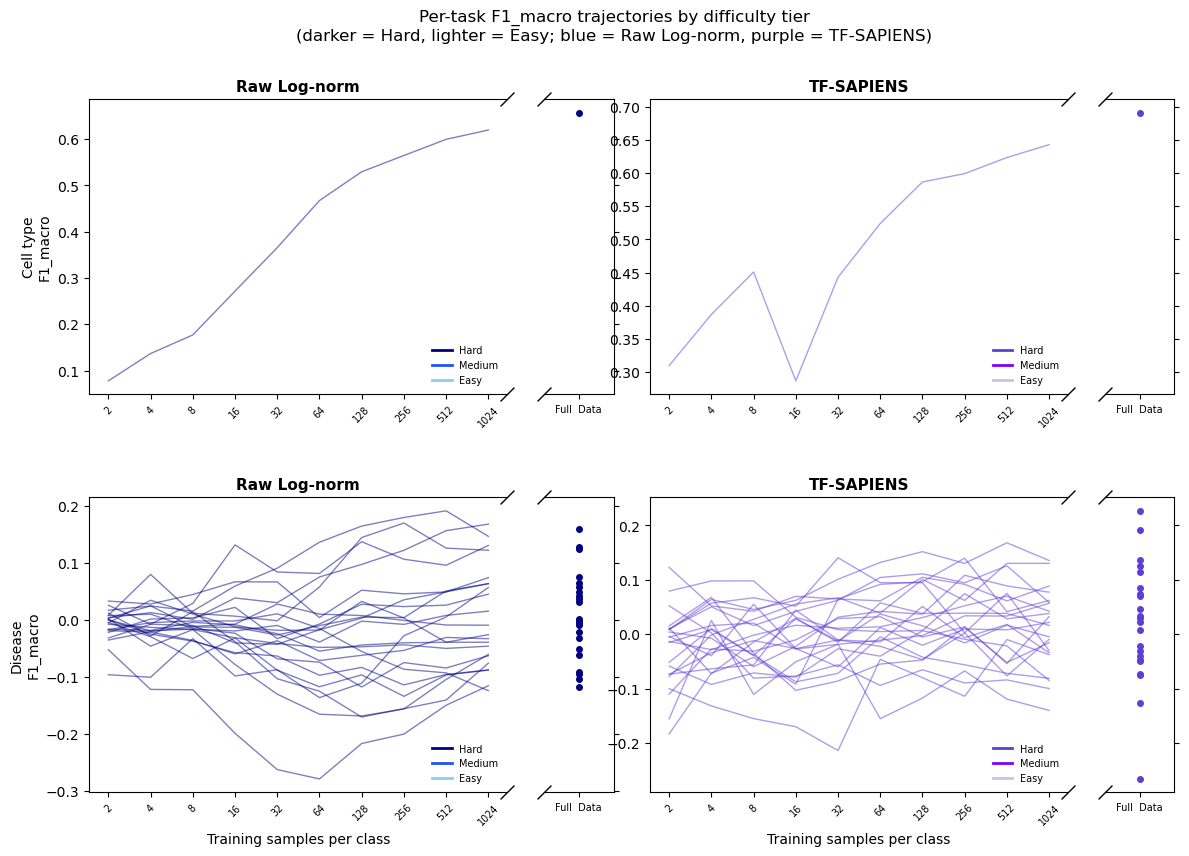

In [174]:

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3, 0.5, 3, 0.5],
              hspace=0.35, wspace=0.15)
# Set the datasets you want to keep

def subset_by_datasets(df, dataset_ids, dataset_col="dataset_id"):
    return df[df[dataset_col].isin(dataset_ids)].copy()

celltype_low_sub   = subset_by_datasets(celltype_low, ["3c75a463-6a87-4132-83a8-c3002624394d"])
celltype_full_sub  = subset_by_datasets(celltype_full,  ["3c75a463-6a87-4132-83a8-c3002624394d"])
difficulty_ct_sub  = subset_by_datasets(difficulty_ct,  ["3c75a463-6a87-4132-83a8-c3002624394d"])

disease_low_sub    = subset_by_datasets(disease_low,  ["3c75a463-6a87-4132-83a8-c3002624394d"])
disease_full_sub   = subset_by_datasets(disease_full,  ["3c75a463-6a87-4132-83a8-c3002624394d"])
difficulty_disease_sub = subset_by_datasets(difficulty_disease,  ["3c75a463-6a87-4132-83a8-c3002624394d"])

panels = [
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (0, celltype_low_sub, celltype_full_sub, difficulty_ct_sub,      "dataset_id", "Cell type", 2, MODEL, TF_SHADES,  "TF-SAPIENS"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   0, RAW,   RAW_SHADES, "Raw Log-norm"),
    (1, disease_low_sub,  disease_full_sub,  difficulty_disease_sub, "task_id",    "Disease",   2, MODEL, TF_SHADES,  "TF-SAPIENS"),
]

for row, df_low, df_full, diff_table, task_col, bm_label, col, feature, shades, feat_label in panels:
    ax1 = fig.add_subplot(gs[row, col])
    ax2 = fig.add_subplot(gs[row, col + 1], sharey=ax1)

    draw_task_lines_panel(ax1, ax2, df_low, df_full, diff_table, task_col,
                           feature, shades)

    ax1.set_ylabel(f"{bm_label}\nF1_macro" if col == 0 else "")
    if row == 1:
        ax1.set_xlabel("Training samples per class")
    ax1.set_title(feat_label, fontsize=11, fontweight="bold")

    # Per-panel tier legend (colors differ Raw vs TF, so one legend per column type)
    legend_handles = [
        plt.Line2D([0], [0], color=shades[t], lw=2, label=t) for t in TIERS
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=7, frameon=False)

fig.suptitle(
    "Per-task F1_macro trajectories by difficulty tier\n"
    "(darker = Hard, lighter = Easy; blue = Raw Log-norm, purple = TF-SAPIENS)",
    y=0.98,
)

#plt.savefig("plots_brief/Raw_TF_F1_macro_per_task_by_difficulty_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

In [171]:
celltype_low[celltype_low['dataset_id'].isin(["3c75a463-6a87-4132-83a8-c3002624394d"])].copy()
celltype_low_sub.MCC


60500    0.010204
60501    0.120413
60502    0.023799
60503    0.194688
60504    0.131863
           ...   
62245    0.642014
62246    0.651461
62247    0.659941
62248    0.608168
62249    0.703189
Name: MCC, Length: 1750, dtype: float64